<a href="https://colab.research.google.com/github/LatiefDataVisionary/DeepRice-Classifier-CNN/blob/main/Copy_of_Refined_EDA_DAC_UNIMED_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 2. Pemuatan Data & Integritas Data (The Foundation)



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')

print('Semua library yang dibutuhkan telah berhasil diimpor.')

Semua library yang dibutuhkan telah berhasil diimpor.


### 2.1 Data Loading & Semicolon Handling



In [ ]:
# Load the CSV file into a DataFrame, specifying the semicolon separator
df = pd.read_csv('/content/Dataset DAC .csv', sep=';')

# Display the first 5 rows of the DataFrame to confirm correct loading
print('5 baris pertama dari DataFrame setelah pemuatan:')
print(df.head())

5 baris pertama dari DataFrame setelah pemuatan:
  Stock_Name              Date  Open  High  Low  Close      Volume
0      ACES   06/11/2007 00:00    75    78   68     75  1274430000
1      ACES   07/11/2007 00:00    75    79   74     77   349330000
2      ACES   08/11/2007 00:00    76    76   73     76    66270000
3      ACES   09/11/2007 00:00    73    74   73     73    40075000
4      ACES   12/11/2007 00:00    69    73   68     69   113285000


### 2.2 Pengecekan Struktur & Tipe Data



In [ ]:
print('Informasi DataFrame:')
df.info()
print('\n')

print('Statistik Deskriptif untuk Kolom Numerik:')
print(df.describe())

Informasi DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 136599 entries, 0 to 136598
Data columns (total 7 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   Stock_Name  136599 non-null  object
 1   Date        136599 non-null  object
 2   Open        136599 non-null  int64 
 3   High        136599 non-null  int64 
 4   Low         136599 non-null  int64 
 5   Close       136599 non-null  int64 
 6   Volume      136599 non-null  int64 
dtypes: int64(5), object(2)
memory usage: 7.3+ MB


Statistik Deskriptif untuk Kolom Numerik:
                Open           High            Low          Close  \
count  136599.000000  136599.000000  136599.000000  136599.000000   
mean     3994.890482    4049.262381    3936.750679    3992.438810   
std      6991.823535    7078.958382    6899.981777    6987.166578   
min         5.000000       5.000000       5.000000       5.000000   
25%       624.000000     635.000000     612.000000     624.00

### 2.3 Data Cleaning: Penanganan Nilai Hilang, Duplikat, dan Konversi Tipe Data



In [ ]:
# Check for missing values
print('Jumlah Nilai Hilang per Kolom:')
print(df.isnull().sum())
print('\n')

# Check for duplicate rows
print('Jumlah Baris Duplikat:')
print(df.duplicated().sum())
print('\n')

# Convert the 'Date' column to datetime objects
df['Date'] = pd.to_datetime(df['Date'], format='%d/%m/%Y %H:%M')

print('DataFrame Info setelah konversi tipe data Date:')
df.info()


Jumlah Nilai Hilang per Kolom:
Stock_Name    0
Date          0
Open          0
High          0
Low           0
Close         0
Volume        0
dtype: int64


Jumlah Baris Duplikat:
0


DataFrame Info setelah konversi tipe data Date:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 136599 entries, 0 to 136598
Data columns (total 7 columns):
 #   Column      Non-Null Count   Dtype         
---  ------      --------------   -----         
 0   Stock_Name  136599 non-null  object        
 1   Date        136599 non-null  datetime64[ns]
 2   Open        136599 non-null  int64         
 3   High        136599 non-null  int64         
 4   Low         136599 non-null  int64         
 5   Close       136599 non-null  int64         
 6   Volume      136599 non-null  int64         
dtypes: datetime64[ns](1), int64(5), object(1)
memory usage: 7.3+ MB


### 2.4 Gaps Analysis



In [ ]:
# Sort the DataFrame by Stock_Name and Date to ensure correct chronological order
df_sorted = df.sort_values(by=['Stock_Name', 'Date']).copy()

# Identify gaps in dates for each stock
gaps_found = {}

for stock_name, group in df_sorted.groupby('Stock_Name'):
    # Calculate the difference in days between consecutive dates
    date_diff = group['Date'].diff().dt.days

    # Identify where the difference is greater than 1 day
    # and the day before is not a Friday (dayofweek = 4) and the current day is not a Monday (dayofweek = 0)
    # This filters out regular weekend gaps
    potential_gaps_indices = date_diff[date_diff > 1].index

    actual_gaps = []
    for idx in potential_gaps_indices:
        prev_date = group.loc[group.index[group.index.get_loc(idx) - 1], 'Date']
        current_date = group.loc[idx, 'Date']

        # Check if the gap is not just a weekend (prev_date is not Fri and current_date is not Mon)
        # Or if the gap is larger than a typical weekend (more than 3 days for a Fri-Mon gap)
        if (current_date - prev_date).days > 1:
            # If it's a gap, record the missing date range
            actual_gaps.append({
                'Previous Date': prev_date,
                'Current Date': current_date,
                'Missing Days': (current_date - prev_date).days - 1
            })

    if actual_gaps:
        gaps_found[stock_name] = actual_gaps


if gaps_found:
    print('Ditemukan celah tanggal (non-akhir pekan) dalam data per saham:')
    for stock, gaps in gaps_found.items():
        print(f'\nStock: {stock}')
        for gap in gaps:
            print(f"  Dari {gap['Previous Date'].strftime('%Y-%m-%d')} ke {gap['Current Date'].strftime('%Y-%m-%d')} (Hilang {gap['Missing Days']} hari)")
else:
    print('Tidak ditemukan celah tanggal yang tidak terduga (di luar akhir pekan) dalam data.')

# Assign the sorted DataFrame back to df for consistency in subsequent steps
df = df_sorted.copy()
print('\nDataFrame telah diurutkan berdasarkan Stock_Name dan Date.')

Streaming output truncated to the last 5000 lines.
  Dari 2016-04-08 ke 2016-04-12 (Hilang 3 hari)
  Dari 2016-04-12 ke 2016-04-20 (Hilang 7 hari)
  Dari 2016-04-22 ke 2016-04-25 (Hilang 2 hari)
  Dari 2016-04-29 ke 2016-05-02 (Hilang 2 hari)
  Dari 2016-05-04 ke 2016-05-09 (Hilang 4 hari)
  Dari 2016-05-13 ke 2016-05-16 (Hilang 2 hari)
  Dari 2016-05-20 ke 2016-05-23 (Hilang 2 hari)
  Dari 2016-05-27 ke 2016-05-30 (Hilang 2 hari)
  Dari 2016-06-03 ke 2016-06-06 (Hilang 2 hari)
  Dari 2016-06-10 ke 2016-06-13 (Hilang 2 hari)
  Dari 2016-06-17 ke 2016-06-20 (Hilang 2 hari)
  Dari 2016-06-24 ke 2016-06-27 (Hilang 2 hari)
  Dari 2016-07-01 ke 2016-07-11 (Hilang 9 hari)
  Dari 2016-07-15 ke 2016-07-18 (Hilang 2 hari)
  Dari 2016-07-22 ke 2016-07-25 (Hilang 2 hari)
  Dari 2016-07-29 ke 2016-08-01 (Hilang 2 hari)
  Dari 2016-08-05 ke 2016-08-08 (Hilang 2 hari)
  Dari 2016-08-12 ke 2016-08-15 (Hilang 2 hari)
  Dari 2016-08-16 ke 2016-08-18 (Hilang 1 hari)
  Dari 2016-08-19 ke 2016-08-22 (Hila

## 3. Analisis Statistik Deskriptif (The Summary)



### 3.1 Statistik Univariat



In [ ]:
print('Statistik Deskriptif Lengkap untuk Kolom Numerik (df.describe()):')
print(df.describe())
print('\n')

print('Statistik Deskriptif untuk Volume (jika ada nilai 0 atau terlalu kecil):')
print(df['Volume'].describe())

print('\nStatistik Deskriptif untuk Daily_Return (jika sudah dihitung):')
if 'Daily_Return' in df.columns:
    print(df['Daily_Return'].describe())
else:
    print('Kolom Daily_Return belum ada di DataFrame.')

Statistik Deskriptif Lengkap untuk Kolom Numerik (df.describe()):
                                Date           Open           High  \
count                         136599  136599.000000  136599.000000   
mean   2014-06-07 09:08:11.063624192    3994.890482    4049.262381   
min              2003-01-02 00:00:00       5.000000       5.000000   
25%              2009-08-07 00:00:00     624.000000     635.000000   
50%              2014-07-16 00:00:00    1589.000000    1613.000000   
75%              2019-06-26 00:00:00    4625.500000    4694.000000   
max              2024-04-29 00:00:00   75790.000000   81154.000000   
std                              NaN    6991.823535    7078.958382   

                 Low          Close        Volume  
count  136599.000000  136599.000000  1.365990e+05  
mean     3936.750679    3992.438810  4.437941e+07  
min         5.000000       5.000000  1.000000e+00  
25%       612.000000     624.000000  3.692572e+06  
50%      1564.000000    1589.000000  1.5007

### 3.2 Analisis Skewness & Kurtosis



Skewness untuk Kolom Numerik:
  Open: 4.4953
  High: 4.4908
  Low: 4.5021
  Close: 4.4964
  Volume: 10.9235


Kurtosis (Excess Kurtosis) untuk Kolom Numerik:
  Open: 26.2714
  High: 26.2175
  Low: 26.3363
  Close: 26.2824
  Volume: 338.4904


Kolom Daily_Return belum ada di DataFrame, tidak dapat menghitung skewness dan kurtosis.

Visualisasi Histogram untuk Menampilkan Skewness Kolom Numerik:


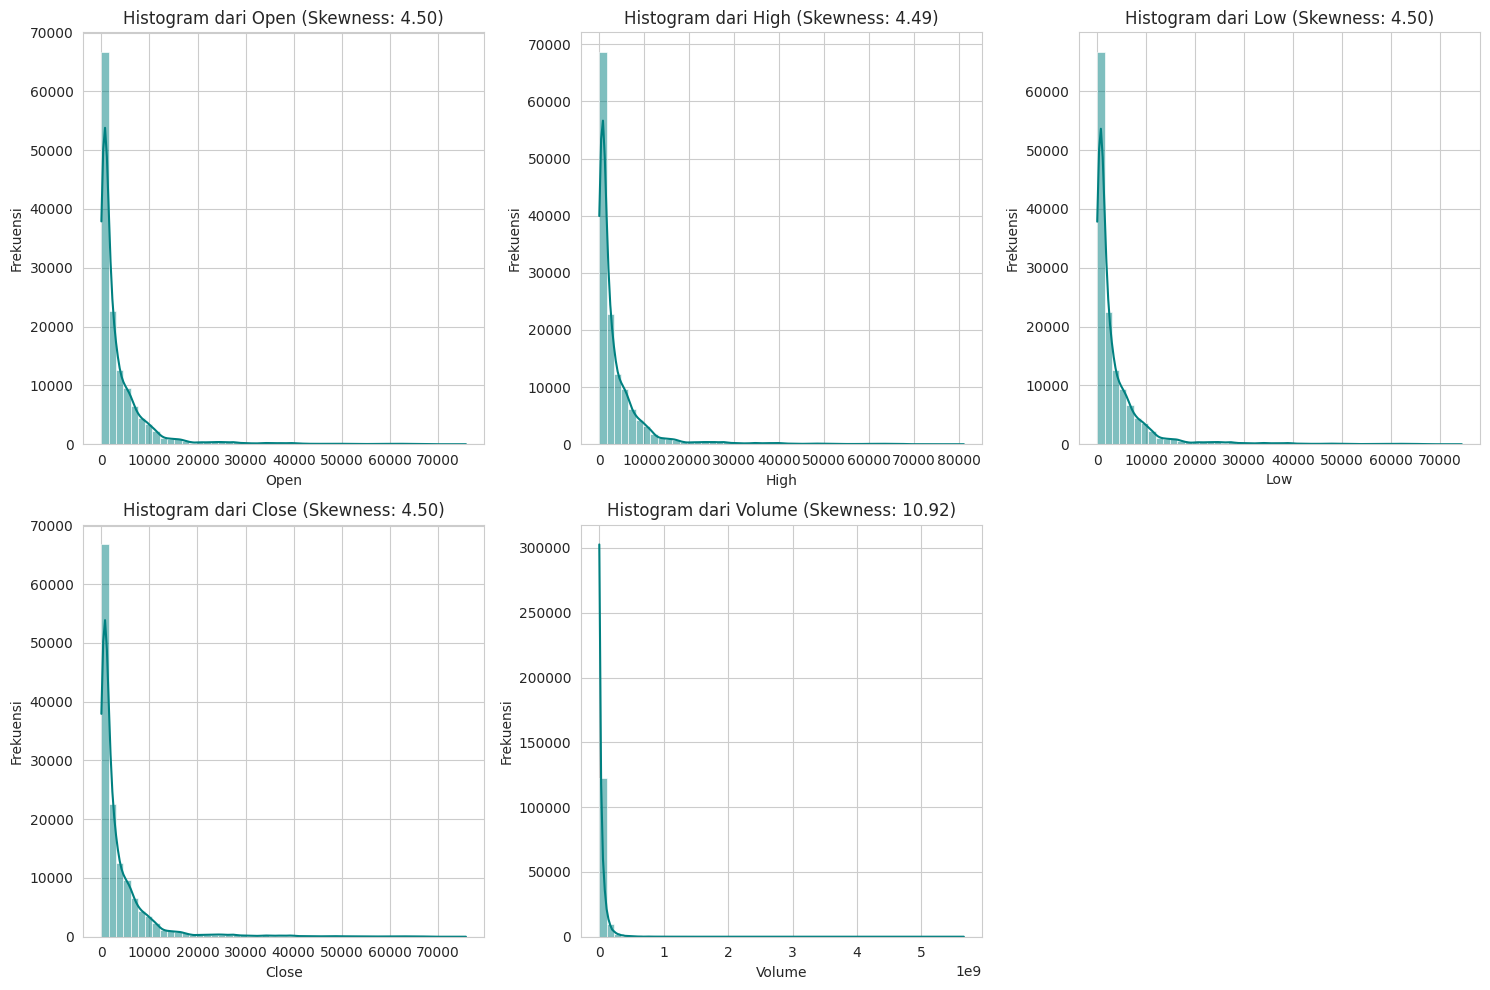

Visualisasi skewness selesai.


In [ ]:
from scipy.stats import skew, kurtosis
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')

numerical_cols_for_shape = ['Open', 'High', 'Low', 'Close', 'Volume']

print('Skewness untuk Kolom Numerik:')
for col in numerical_cols_for_shape:
    print(f'  {col}: {skew(df[col].dropna()):.4f}')
print('\n')

print('Kurtosis (Excess Kurtosis) untuk Kolom Numerik:')
for col in numerical_cols_for_shape:
    print(f'  {col}: {kurtosis(df[col].dropna()):.4f}') # default scipy.stats.kurtosis is excess kurtosis
print('\n')

if 'Daily_Return' in df.columns:
    print('Skewness untuk Daily_Return:')
    print(f'  Daily_Return: {skew(df['Daily_Return'].dropna()):.4f}')
    print('\n')

    print('Kurtosis (Excess Kurtosis) untuk Daily_Return:')
    print(f'  Daily_Return: {kurtosis(df['Daily_Return'].dropna()):.4f}')
else:
    print('Kolom Daily_Return belum ada di DataFrame, tidak dapat menghitung skewness dan kurtosis.')

# --- Visualisasi Skewness (tambahan sesuai permintaan) ---
print('\nVisualisasi Histogram untuk Menampilkan Skewness Kolom Numerik:')

plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols_for_shape):
    plt.subplot(2, 3, i + 1) # Menyesuaikan subplot untuk 5 kolom
    sns.histplot(df[col].dropna(), kde=True, bins=50, color='teal')
    plt.title(f'Histogram dari {col} (Skewness: {skew(df[col].dropna()):.2f})', fontsize=12)
    plt.xlabel(col, fontsize=10)
    plt.ylabel('Frekuensi', fontsize=10)
plt.tight_layout()
plt.show()

print('Visualisasi skewness selesai.')

### 3.3 Outlier Detection (Z-Score/IQR)



Identifikasi Outlier menggunakan Z-Score (threshold = 3):
  Open: 3338 outlier
  High: 3336 outlier
  Low: 3331 outlier
  Close: 3333 outlier
  Volume: 2021 outlier


Identifikasi Outlier menggunakan IQR (1.5 * IQR):
  Open: 10616 outlier
  High: 10616 outlier
  Low: 10581 outlier
  Close: 10612 outlier
  Volume: 11458 outlier


Kolom Daily_Return belum ada di DataFrame, tidak dapat melakukan deteksi outlier.

Visualisasi Boxplot untuk Kolom dengan Outlier Signifikan:


/tmp/ipykernel_414/601237719.py:70: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y=df[col], palette='magma')
/tmp/ipykernel_414/601237719.py:70: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y=df[col], palette='magma')


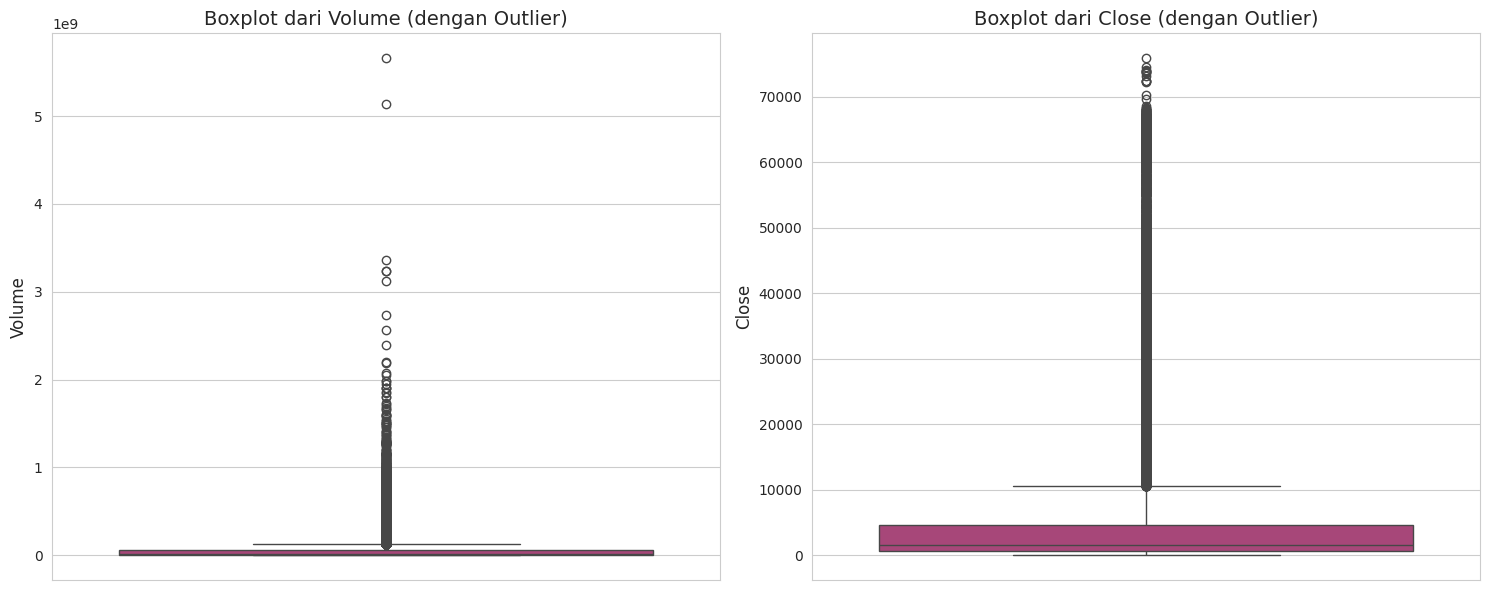

Visualisasi outlier selesai.


In [ ]:
from scipy.stats import zscore
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np # Pastikan numpy diimpor

sns.set_style('whitegrid')

# Identifikasi outlier menggunakan Z-Score
print('Identifikasi Outlier menggunakan Z-Score (threshold = 3):')
numerical_cols_for_outliers = ['Open', 'High', 'Low', 'Close', 'Volume']

for col in numerical_cols_for_outliers:
    # Menghindari NaN dalam perhitungan z-score
    col_data = df[col].dropna()
    if not col_data.empty:
        z_scores = np.abs(zscore(col_data))
        outliers_zscore = col_data[z_scores > 3]
        print(f'  {col}: {len(outliers_zscore)} outlier')
    else:
        print(f'  {col}: Data kosong atau hanya NaN.')
print('\n')

# Identifikasi outlier menggunakan IQR
print('Identifikasi Outlier menggunakan IQR (1.5 * IQR):')
for col in numerical_cols_for_outliers:
    col_data = df[col].dropna()
    if not col_data.empty:
        Q1 = col_data.quantile(0.25)
        Q3 = col_data.quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        outliers_iqr = col_data[(col_data < lower_bound) | (col_data > upper_bound)]
        print(f'  {col}: {len(outliers_iqr)} outlier')
    else:
        print(f'  {col}: Data kosong atau hanya NaN.')
print('\n')

if 'Daily_Return' in df.columns:
    daily_return_data = df['Daily_Return'].dropna()
    if not daily_return_data.empty:
        # Z-Score for Daily_Return
        z_scores_dr = np.abs(zscore(daily_return_data))
        outliers_zscore_dr = daily_return_data[z_scores_dr > 3]
        print(f"  Daily_Return (Z-Score): {len(outliers_zscore_dr)} outlier")

        # IQR for Daily_Return
        Q1_dr = daily_return_data.quantile(0.25)
        Q3_dr = daily_return_data.quantile(0.75)
        IQR_dr = Q3_dr - Q1_dr
        lower_bound_dr = Q1_dr - 1.5 * IQR_dr
        upper_bound_dr = Q3_dr + 1.5 * IQR_dr
        outliers_iqr_dr = daily_return_data[(daily_return_data < lower_bound_dr) | (daily_return_data > upper_bound_dr)]
        print(f"  Daily_Return (IQR): {len(outliers_iqr_dr)} outlier")
    else:
        print('  Daily_Return: Data kosong atau hanya NaN.')
else:
    print('Kolom Daily_Return belum ada di DataFrame, tidak dapat melakukan deteksi outlier.')


# --- Visualisasi Outlier (tambahan sesuai permintaan) ---
print('\nVisualisasi Boxplot untuk Kolom dengan Outlier Signifikan:')

# Memilih kolom dengan outlier paling banyak atau paling relevan untuk visualisasi
visualize_cols = ['Volume', 'Close'] # Contoh: Volume dan Close Price

plt.figure(figsize=(15, 6))
for i, col in enumerate(visualize_cols):
    plt.subplot(1, len(visualize_cols), i + 1)
    sns.boxplot(y=df[col], palette='magma')
    plt.title(f'Boxplot dari {col} (dengan Outlier)', fontsize=14)
    plt.ylabel(col, fontsize=12)
plt.tight_layout()
plt.show()

print('Visualisasi outlier selesai.')

## 4. Analisis Univariat: Distribusi & Karakteristik (The Distribution)



### 4.1 Visualisasi Fitur Numerik (Harga dan Volume)



Generating distribution plots for numerical columns...


/tmp/ipykernel_414/1093290091.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y=df[col], ax=axes[i, 1], palette='viridis')
/tmp/ipykernel_414/1093290091.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y=df[col], ax=axes[i, 1], palette='viridis')
/tmp/ipykernel_414/1093290091.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y=df[col], ax=axes[i, 1], palette='viridis')
/tmp/ipykernel_414/1093290091.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variab

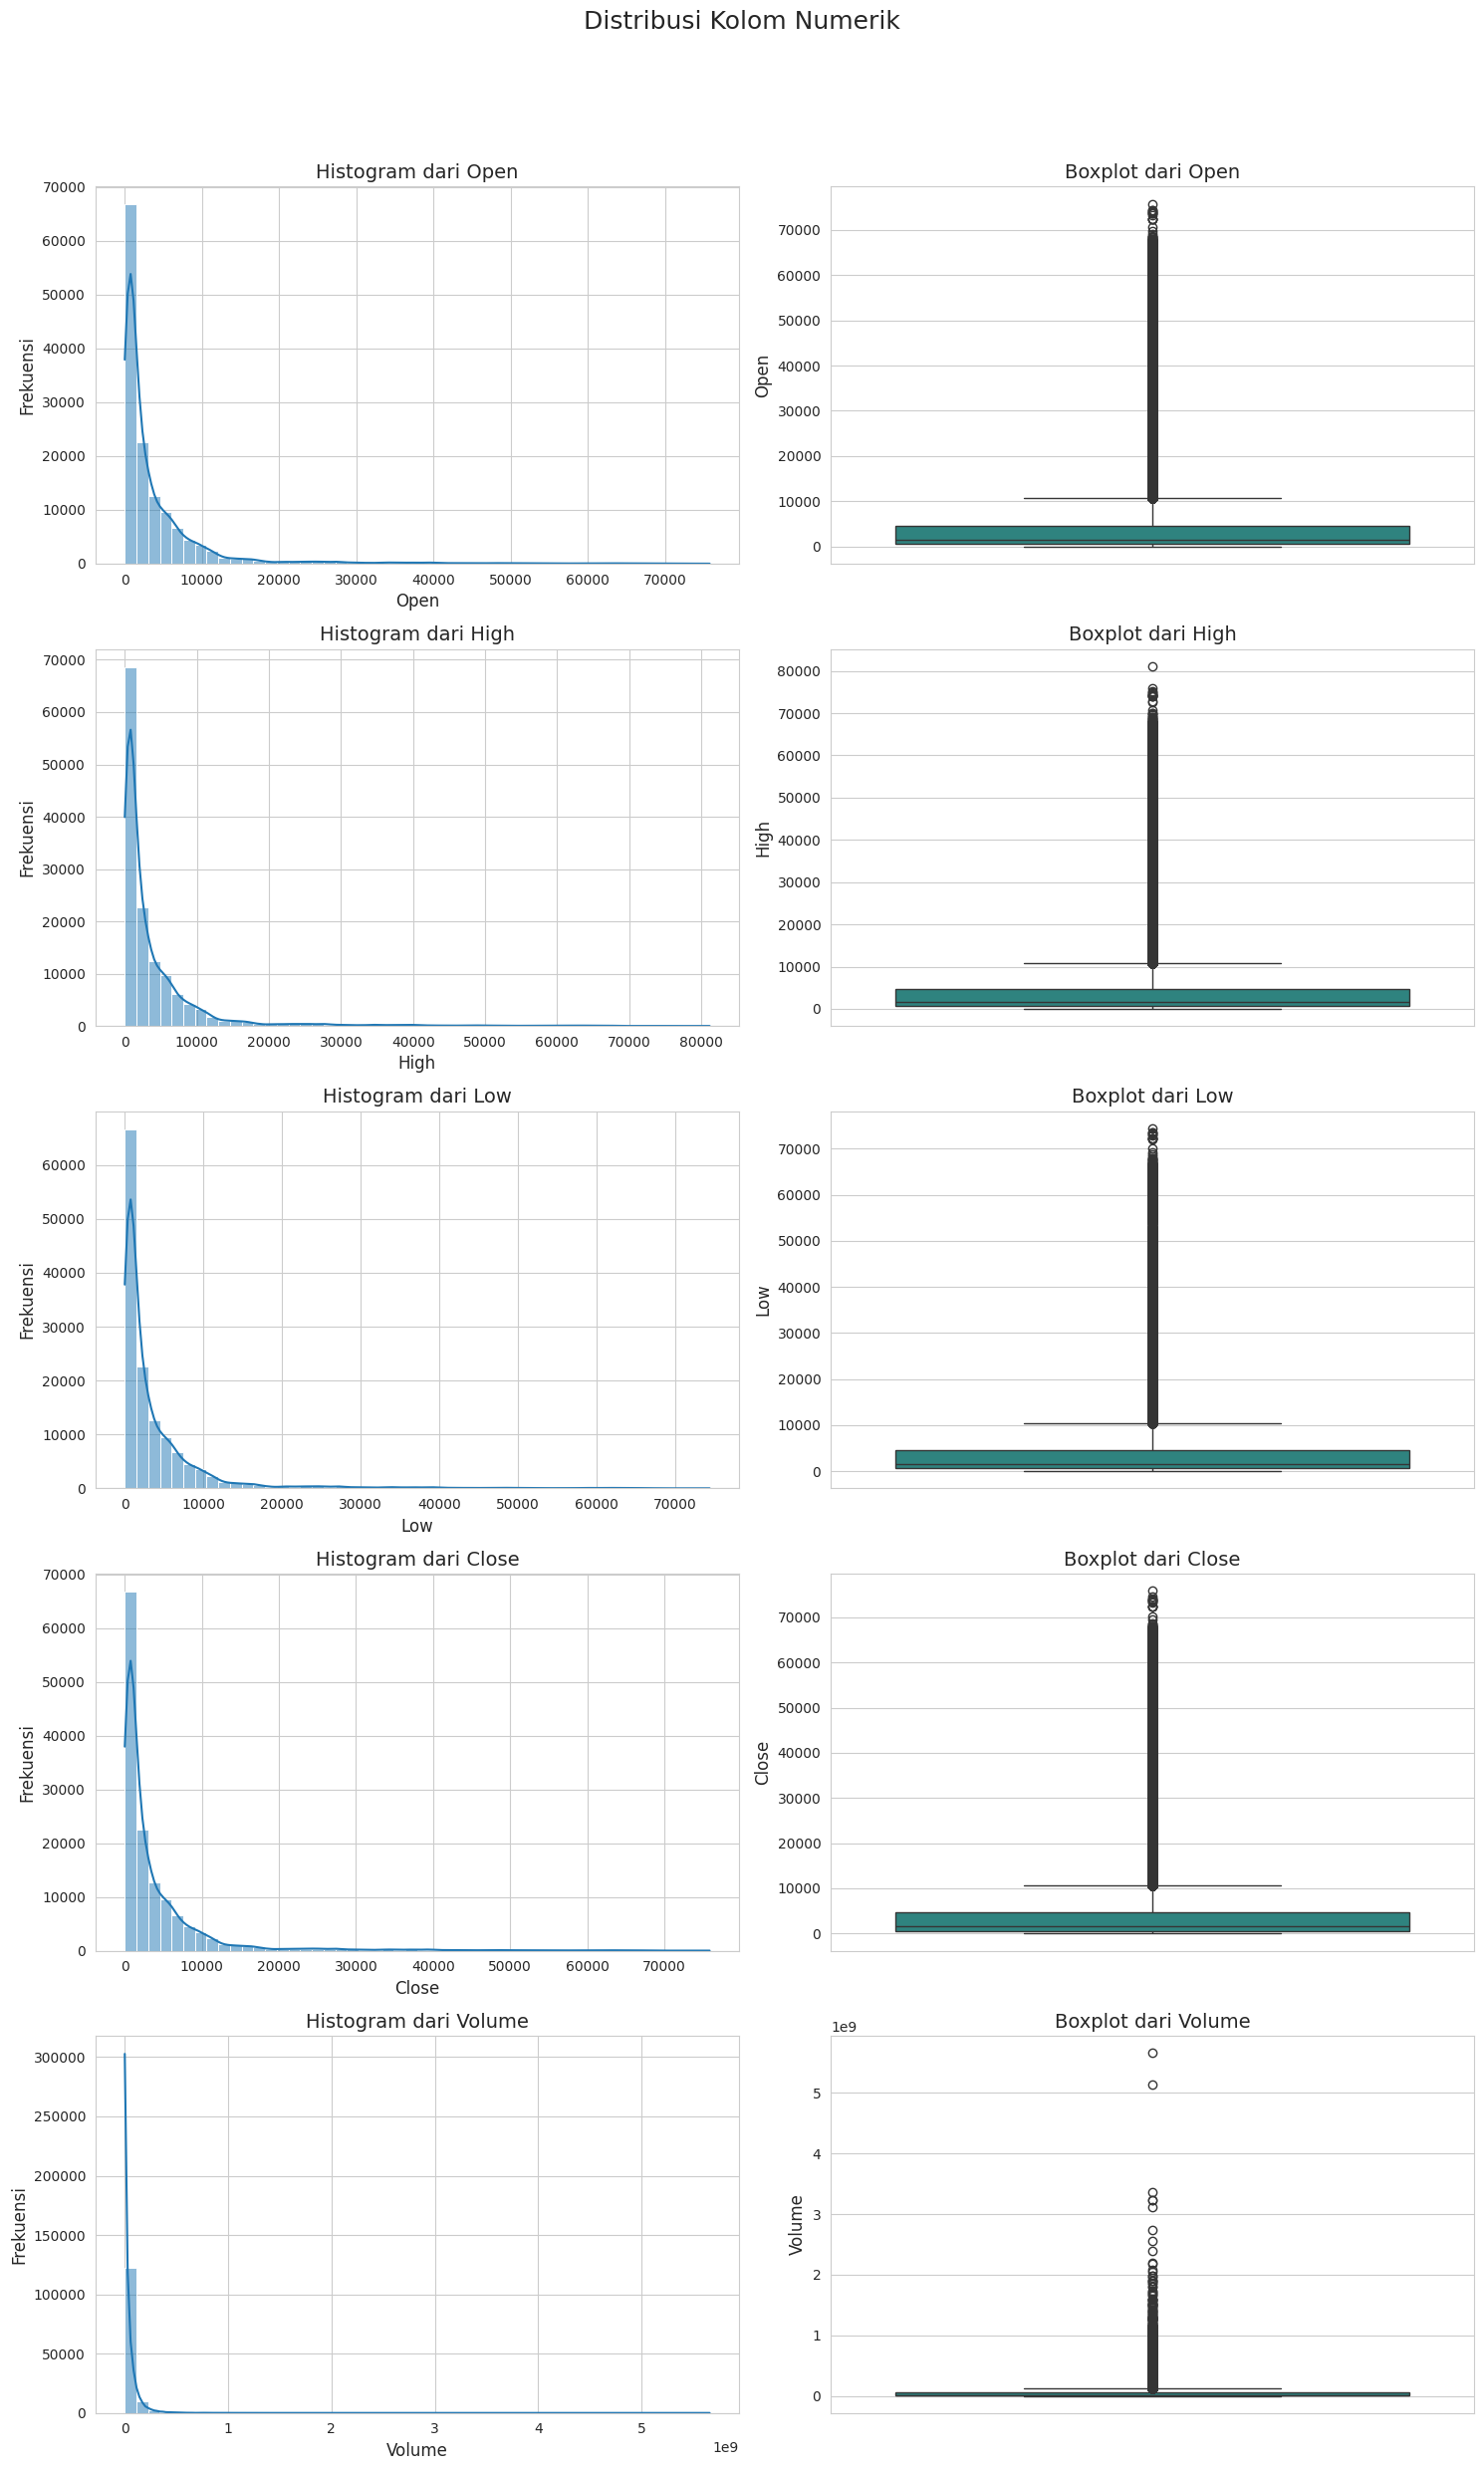

Distribution plots generated.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')

# Define numerical columns to plot
numerical_cols_dist = ['Open', 'High', 'Low', 'Close', 'Volume']

print('Generating distribution plots for numerical columns...')

# Create subplots for histograms and boxplots
fig, axes = plt.subplots(len(numerical_cols_dist), 2, figsize=(15, 5 * len(numerical_cols_dist)))
fig.suptitle('Distribusi Kolom Numerik', y=1.02, fontsize=18)

for i, col in enumerate(numerical_cols_dist):
    # Histogram
    sns.histplot(df[col], kde=True, ax=axes[i, 0], bins=50)
    axes[i, 0].set_title(f'Histogram dari {col}', fontsize=14)
    axes[i, 0].set_xlabel(col, fontsize=12)
    axes[i, 0].set_ylabel('Frekuensi', fontsize=12)

    # Boxplot
    sns.boxplot(y=df[col], ax=axes[i, 1], palette='viridis')
    axes[i, 1].set_title(f'Boxplot dari {col}', fontsize=14)
    axes[i, 1].set_ylabel(col, fontsize=12)

plt.tight_layout(rect=[0, 0.03, 1, 0.98]) # Adjust layout to prevent suptitle overlap
plt.show()

print('Distribution plots generated.')

### 4.2 Analisis Fitur Kategorikal (`Stock_Name`)



Jumlah saham unik dalam dataset: 29

Frekuensi Data (Kuantitas dan Persentase) untuk SEMUA Saham:
Stock_Name  Count  Percentage
     INDF    5163        3.78
     GGRM    5150        3.77
     ASII    5150        3.77
     UNTR    5146        3.77
     ICBP    5146        3.77
     INTP    5145        3.77
     MEDC    5145        3.77
     PTBA    5143        3.77
     INKP    5143        3.77
     BRPT    5110        3.74
     BMRI    5020        3.67
     UNVR    4980        3.65
     BBRI    4938        3.61
     PGAS    4916        3.60
     KLBF    4903        3.59
     BBNI    4887        3.58
     BBCA    4803        3.52
     TLKM    4731        3.46
     MAPI    4679        3.43
     EXCL    4469        3.27
     SMGR    4451        3.26
     AKRA    4442        3.25
     INCO    4432        3.24
     CPIN    4392        3.22
     ACES    3943        2.89
     ITMG    3898        2.85
     ANTM    3826        2.80
     ADRO    3803        2.78
     AMRT    3645        2.67




/tmp/ipykernel_414/2068103601.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_15_for_plot.index, y=top_15_for_plot.values, palette='viridis')


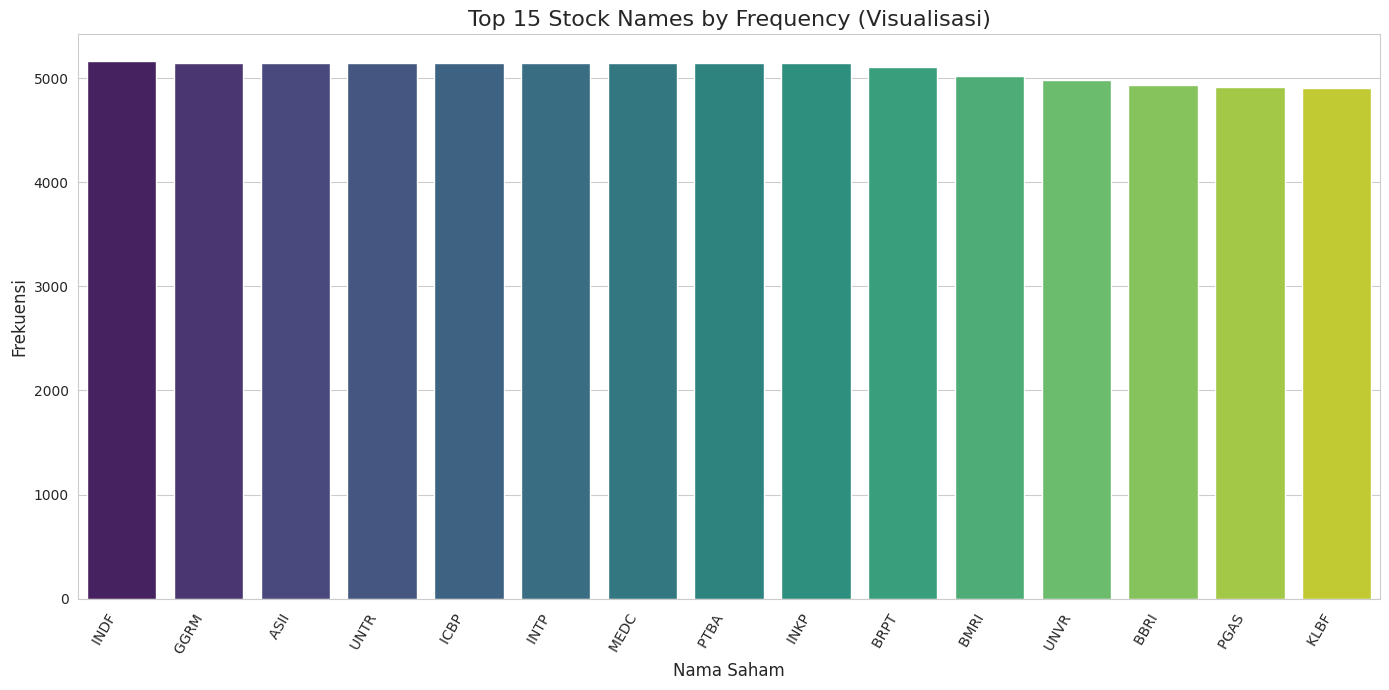

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd # Memastikan pandas diimpor untuk DataFrame

sns.set_style('whitegrid')

# Jumlah saham unik
num_unique_stocks = df['Stock_Name'].nunique()
print(f'Jumlah saham unik dalam dataset: {num_unique_stocks}\n')

# Hitung frekuensi untuk SEMUA saham
all_stocks_counts = df['Stock_Name'].value_counts()

# Hitung persentase untuk SEMUA saham
total_rows = len(df)
all_stocks_percentage = round((all_stocks_counts / total_rows) * 100, 2)

# Buat DataFrame untuk output tabel SEMUA saham
all_stocks_summary = pd.DataFrame({
    'Stock_Name': all_stocks_counts.index,
    'Count': all_stocks_counts.values,
    'Percentage': all_stocks_percentage.values
})

print('Frekuensi Data (Kuantitas dan Persentase) untuk SEMUA Saham:')
print(all_stocks_summary.to_string(index=False)) # Menggunakan to_string agar format tabel terlihat rapi di output konsol
print('\n')

# Visualisasi HANYA 15 saham teratas
top_15_for_plot = all_stocks_counts.head(15) # Ambil 15 teratas khusus untuk visualisasi

plt.figure(figsize=(14, 7))
sns.barplot(x=top_15_for_plot.index, y=top_15_for_plot.values, palette='viridis')
plt.title('Top 15 Stock Names by Frequency (Visualisasi)', fontsize=16)
plt.xlabel('Nama Saham', fontsize=12)
plt.ylabel('Frekuensi', fontsize=12)
plt.xticks(rotation=60, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()

### 4.3 Feature Engineering: Time-Based Features



In [ ]:
import pandas as pd

# Ekstrak fitur-fitur berbasis waktu dari kolom 'Date'
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day
df['Day_of_Week'] = df['Date'].dt.dayofweek  # Monday=0, Sunday=6
df['Day_of_Year'] = df['Date'].dt.dayofyear
df['Week_of_Year'] = df['Date'].dt.isocalendar().week.astype(int)
df['Quarter'] = df['Date'].dt.quarter
df['Is_Month_Start'] = df['Date'].dt.is_month_start.astype(int)
df['Is_Month_End'] = df['Date'].dt.is_month_end.astype(int)
df['Is_Quarter_Start'] = df['Date'].dt.is_quarter_start.astype(int)
df['Is_Quarter_End'] = df['Date'].dt.is_quarter_end.astype(int)
df['Is_Year_Start'] = df['Date'].dt.is_year_start.astype(int)
df['Is_Year_End'] = df['Date'].dt.is_year_end.astype(int)
df['Is_Weekend'] = ((df['Date'].dt.dayofweek == 5) | (df['Date'].dt.dayofweek == 6)).astype(int)

# Tampilkan 5 baris pertama dengan fitur baru
print('DataFrame dengan fitur berbasis waktu baru:')
print(df.head())
print('\n')

# Verifikasi tipe data baru
print('DataFrame Info setelah Feature Engineering:')
df.info()

DataFrame dengan fitur berbasis waktu baru:
  Stock_Name       Date  Open  High  Low  Close      Volume  Year  Month  Day  \
0      ACES  2007-11-06    75    78   68     75  1274430000  2007     11    6   
1      ACES  2007-11-07    75    79   74     77   349330000  2007     11    7   
2      ACES  2007-11-08    76    76   73     76    66270000  2007     11    8   
3      ACES  2007-11-09    73    74   73     73    40075000  2007     11    9   
4      ACES  2007-11-12    69    73   68     69   113285000  2007     11   12   

   ...  Day_of_Year  Week_of_Year  Quarter  Is_Month_Start  Is_Month_End  \
0  ...          310            45        4               0             0   
1  ...          311            45        4               0             0   
2  ...          312            45        4               0             0   
3  ...          313            45        4               0             0   
4  ...          316            46        4               0             0   

   Is_Quarte

## 5. Analisis Deret Waktu: Tren & Volatilitas (The Temporal Nature)



### 5.1 Visualisasi Pergerakan Harga dan Volume



Melakukan analisis tren waktu untuk saham: ['INDF ', 'GGRM ', 'ASII ', 'UNTR ', 'ICBP ', 'INTP ', 'MEDC ']



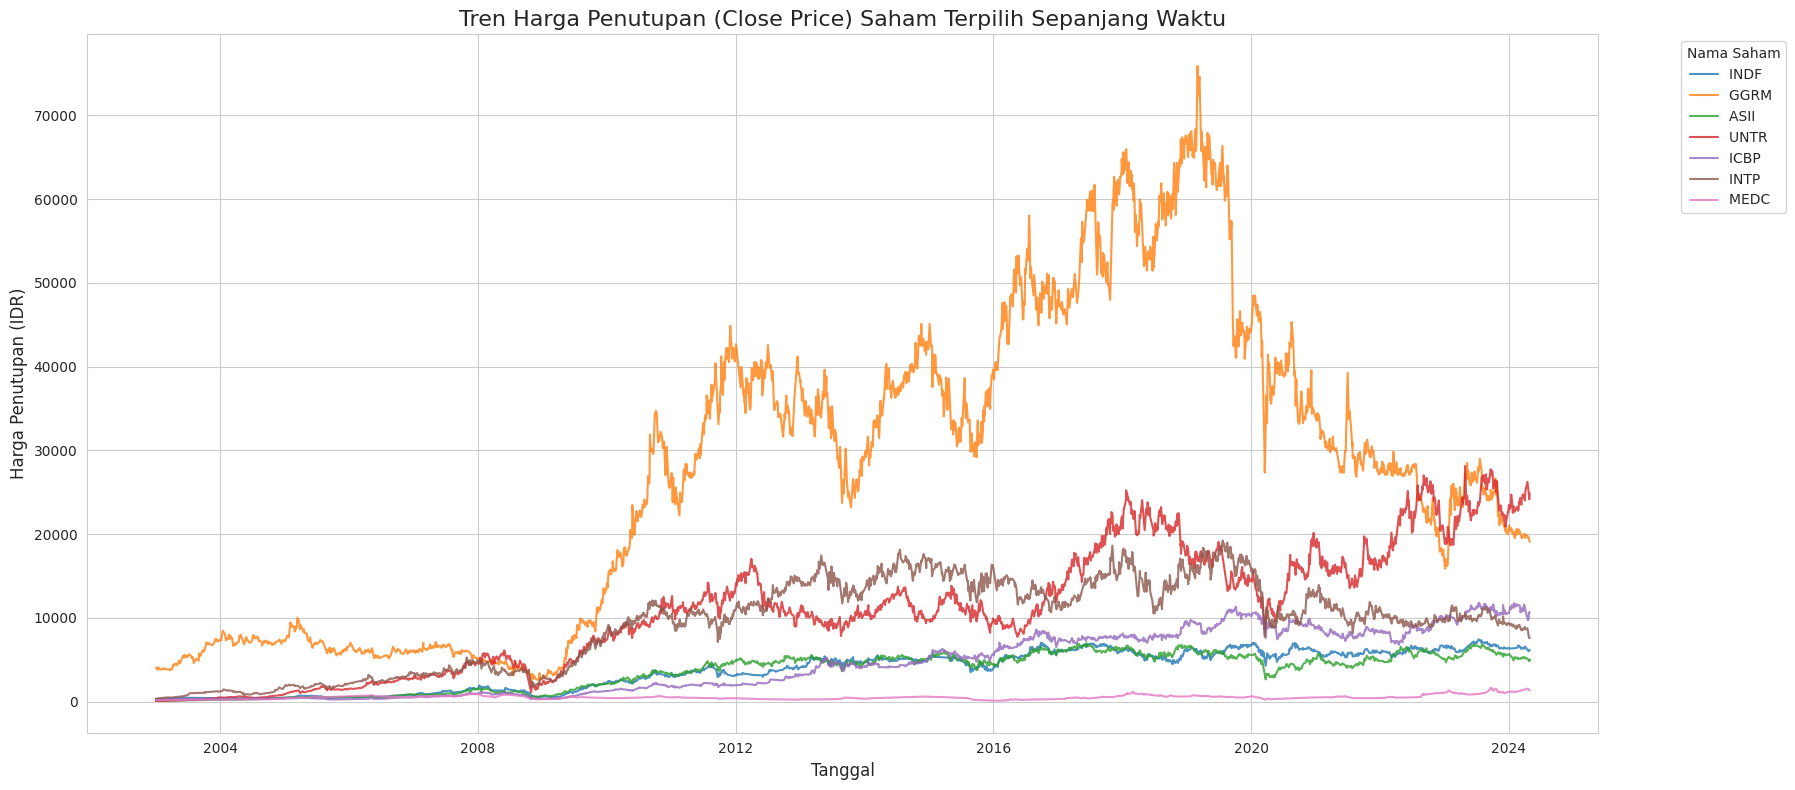

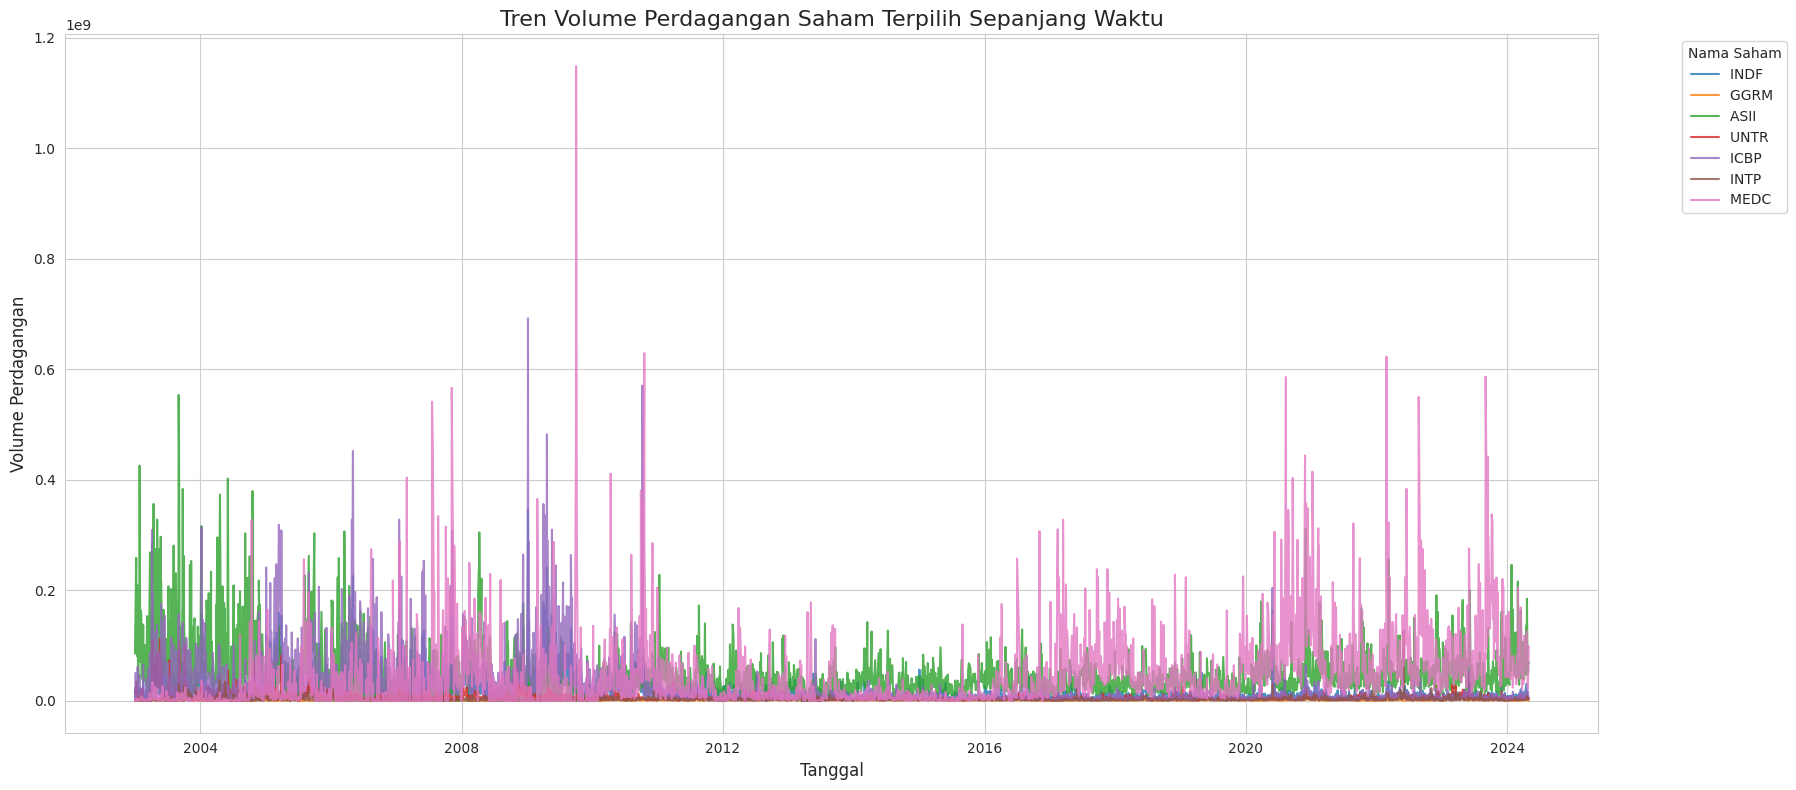

Visualisasi tren harga dan volume selesai.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')

# Memilih beberapa saham teratas untuk visualisasi tren waktu (misalnya 7 saham teratas)
top_stocks_for_trend = df['Stock_Name'].value_counts().head(7).index.tolist()

print(f"Melakukan analisis tren waktu untuk saham: {top_stocks_for_trend}\n")

# Plot tren harga penutupan (Close) dari waktu ke waktu untuk saham terpilih
plt.figure(figsize=(18, 8))
for stock in top_stocks_for_trend:
    stock_df_temp = df[df['Stock_Name'] == stock].sort_values(by='Date')
    plt.plot(stock_df_temp['Date'], stock_df_temp['Close'], label=stock, alpha=0.8)
plt.title('Tren Harga Penutupan (Close Price) Saham Terpilih Sepanjang Waktu', fontsize=16)
plt.xlabel('Tanggal', fontsize=12)
plt.ylabel('Harga Penutupan (IDR)', fontsize=12)
plt.legend(title='Nama Saham', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()

# Plot tren Volume dari waktu ke waktu untuk saham terpilih
plt.figure(figsize=(18, 8))
for stock in top_stocks_for_trend:
    stock_df_temp = df[df['Stock_Name'] == stock].sort_values(by='Date')
    plt.plot(stock_df_temp['Date'], stock_df_temp['Volume'], label=stock, alpha=0.8)
plt.title('Tren Volume Perdagangan Saham Terpilih Sepanjang Waktu', fontsize=16)
plt.xlabel('Tanggal', fontsize=12)
plt.ylabel('Volume Perdagangan', fontsize=12)
plt.legend(title='Nama Saham', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()

print('Visualisasi tren harga dan volume selesai.')

In [ ]:
# Install mplfinance for candlestick charts if not already installed
!pip install mplfinance

print('Pustaka mplfinance berhasil diinstal.')

Pustaka mplfinance berhasil diinstal.


### 5.2 Candlestick Chart



Membuat Candlestick Chart untuk saham: INDF 



/usr/local/lib/python3.12/dist-packages/mplfinance/_arg_validators.py:84: UserWarning: 


            POSSIBLE TO SEE DETAILS (Candles, Ohlc-Bars, Etc.)
   For more information see:
   - https://github.com/matplotlib/mplfinance/wiki/Plotting-Too-Much-Data
   
   TO SILENCE THIS WARNING, set `type='line'` in `mpf.plot()`
   OR set kwarg `warn_too_much_data=N` where N is an integer 
   LARGER than the number of data points you want to plot.

  warnings.warn('\n\n ================================================================= '+


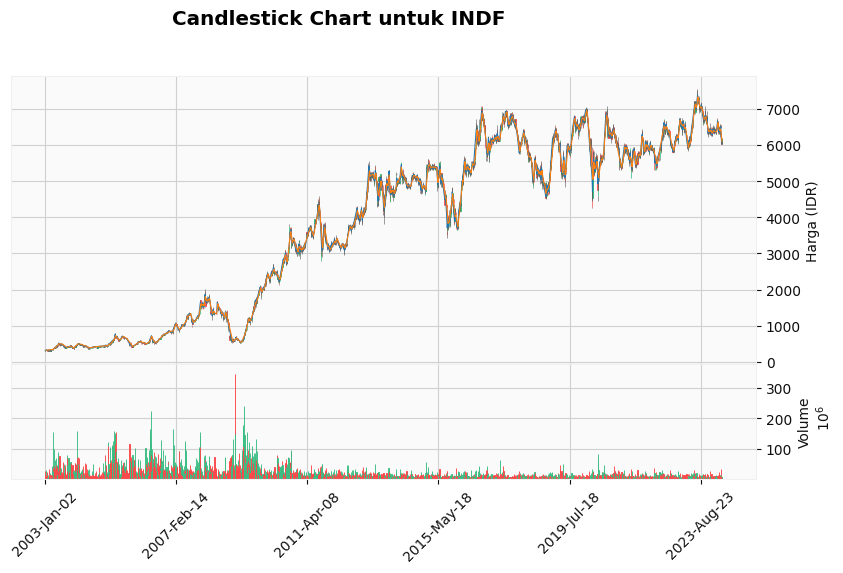

Candlestick Chart untuk INDF  berhasil dibuat.


In [ ]:
import mplfinance as mpf

# Pilih satu saham dari top_stocks_for_trend untuk visualisasi candlestick
# Misalnya, saham pertama dalam daftar top_stocks_for_trend
# Pastikan top_stocks_for_trend sudah didefinisikan dari analisis sebelumnya
# Jika belum, kita bisa ambil dari top_stocks yang sudah ada atau mendefinisikan ulang
if 'top_stocks_for_trend' not in locals():
    top_stocks_for_trend = df['Stock_Name'].value_counts().head(7).index.tolist()

selected_stock = top_stocks_for_trend[0]

print(f"Membuat Candlestick Chart untuk saham: {selected_stock}\n")

# Filter data untuk saham yang dipilih dan set indeks 'Date' sebagai DatetimeIndex
stock_df_candle = df[df['Stock_Name'] == selected_stock].set_index('Date')
stock_df_candle = stock_df_candle.sort_index()

# Memastikan kolom adalah numerik
stock_df_candle[['Open', 'High', 'Low', 'Close', 'Volume']] = stock_df_candle[['Open', 'High', 'Low', 'Close', 'Volume']].apply(pd.to_numeric, errors='coerce')

# Filter out any rows with NaN values that might result from type conversion issues or data gaps
stock_df_candle.dropna(subset=['Open', 'High', 'Low', 'Close', 'Volume'], inplace=True)

# Buat Candlestick Chart
# Menggunakan `type='candle'` untuk grafik candlestick
# `mav` untuk Moving Averages (misalnya 5 dan 10 hari)
# `volume=True` untuk menyertakan grafik volume di bagian bawah
mpf.plot(stock_df_candle, type='candle', style='yahoo',
         title=f'Candlestick Chart untuk {selected_stock}',
         ylabel='Harga (IDR)', ylabel_lower='Volume',
         figratio=(18,10), figscale=1.0,
         volume=True, mav=(5, 10)) # Menambahkan Moving Averages untuk 5 dan 10 hari

print(f'Candlestick Chart untuk {selected_stock} berhasil dibuat.')

### 5.3 Analisis Volume vs Harga



Melakukan analisis Volume vs Harga untuk saham: ['INDF ', 'GGRM ', 'ASII ']



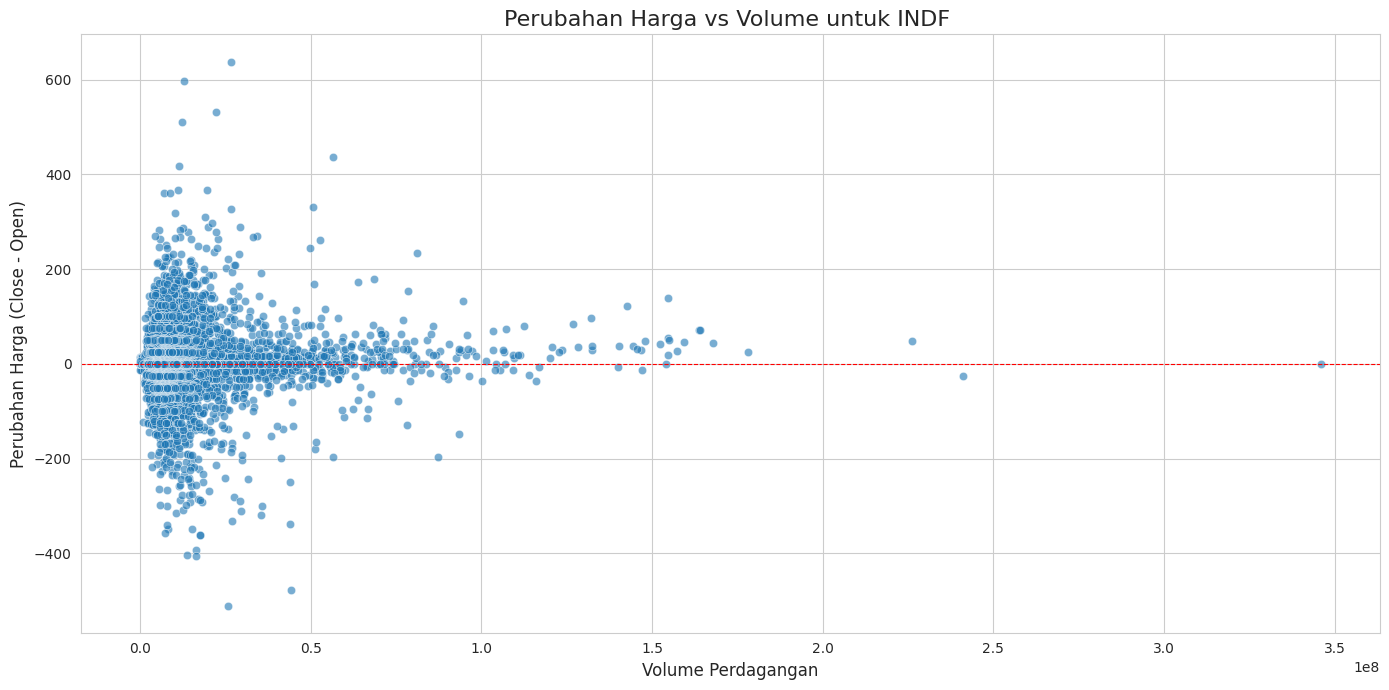

Korelasi antara Harga Penutupan dan Volume untuk INDF : -0.3857



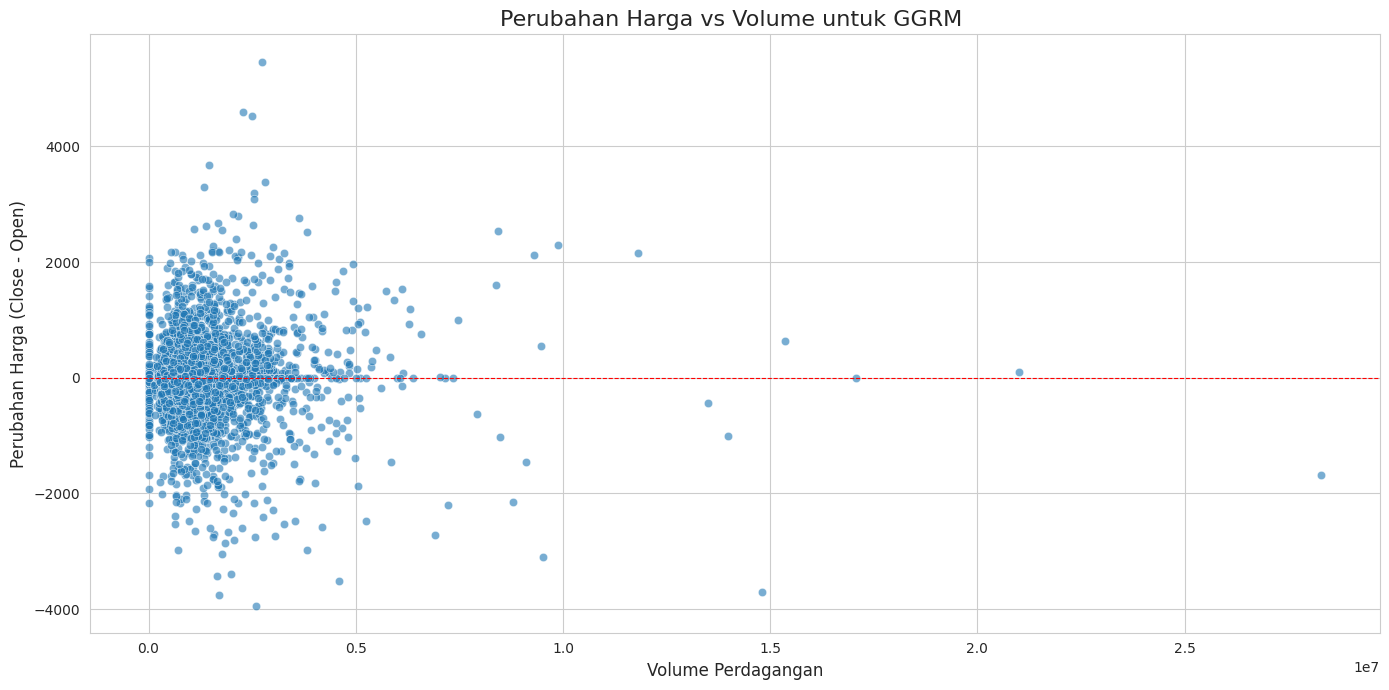

Korelasi antara Harga Penutupan dan Volume untuk GGRM : 0.1641



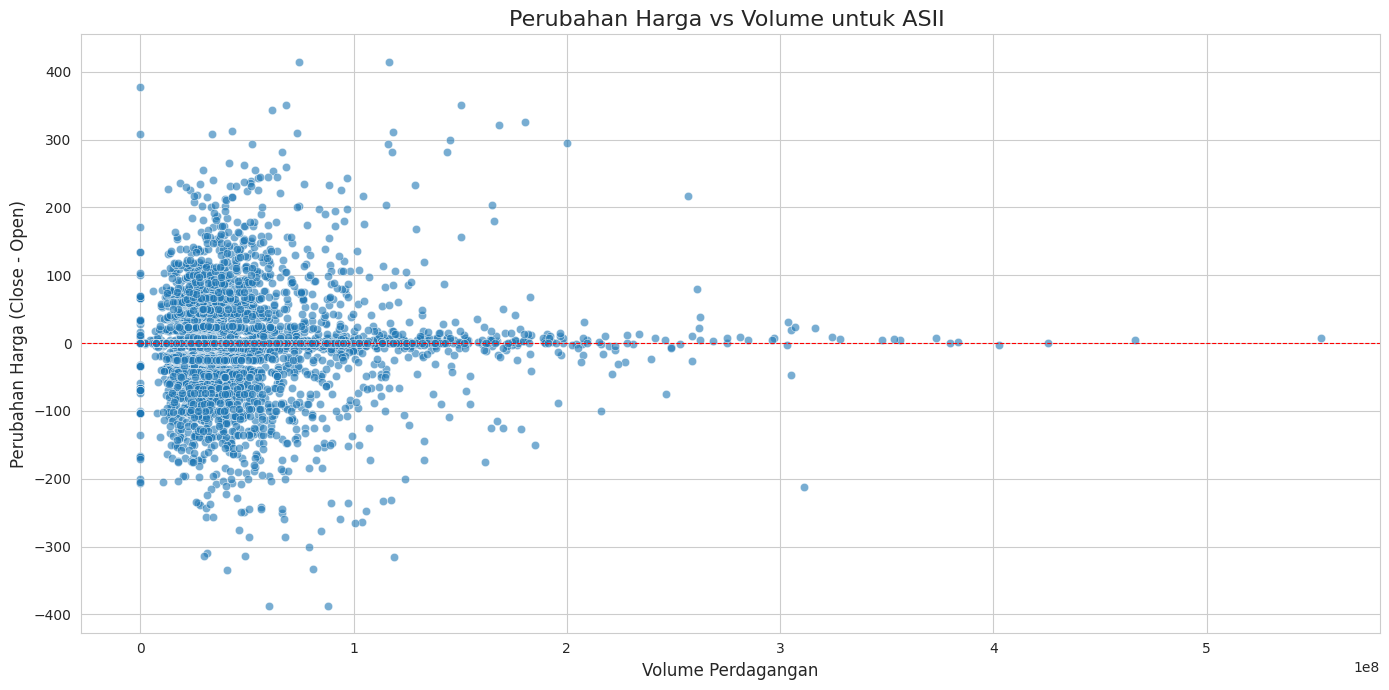

Korelasi antara Harga Penutupan dan Volume untuk ASII : -0.1922

Analisis Volume vs Harga selesai.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')

# Pilih beberapa saham teratas untuk analisis ini (misalnya 3 saham teratas)
top_stocks_for_vol_price = df['Stock_Name'].value_counts().head(3).index.tolist()

print(f"Melakukan analisis Volume vs Harga untuk saham: {top_stocks_for_vol_price}\n")

for stock in top_stocks_for_vol_price:
    stock_df = df[df['Stock_Name'] == stock].sort_values(by='Date')
    stock_df['Price_Change'] = stock_df['Close'] - stock_df['Open']

    # Scatter plot Price Change vs Volume
    plt.figure(figsize=(14, 7))
    sns.scatterplot(x='Volume', y='Price_Change', data=stock_df, alpha=0.6)
    plt.title(f'Perubahan Harga vs Volume untuk {stock}', fontsize=16)
    plt.xlabel('Volume Perdagangan', fontsize=12)
    plt.ylabel('Perubahan Harga (Close - Open)', fontsize=12)
    plt.axhline(0, color='red', linestyle='--', linewidth=0.8) # Garis referensi untuk perubahan harga nol
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # Korelasi antara Close Price dan Volume
    correlation = stock_df['Close'].corr(stock_df['Volume'])
    print(f"Korelasi antara Harga Penutupan dan Volume untuk {stock}: {correlation:.4f}\n")

print('Analisis Volume vs Harga selesai.')

### 5.4 Rolling Statistics (Moving Average dan Standard Deviation)



Melakukan analisis Rolling Statistics untuk saham: ['INDF ', 'GGRM ', 'ASII ']



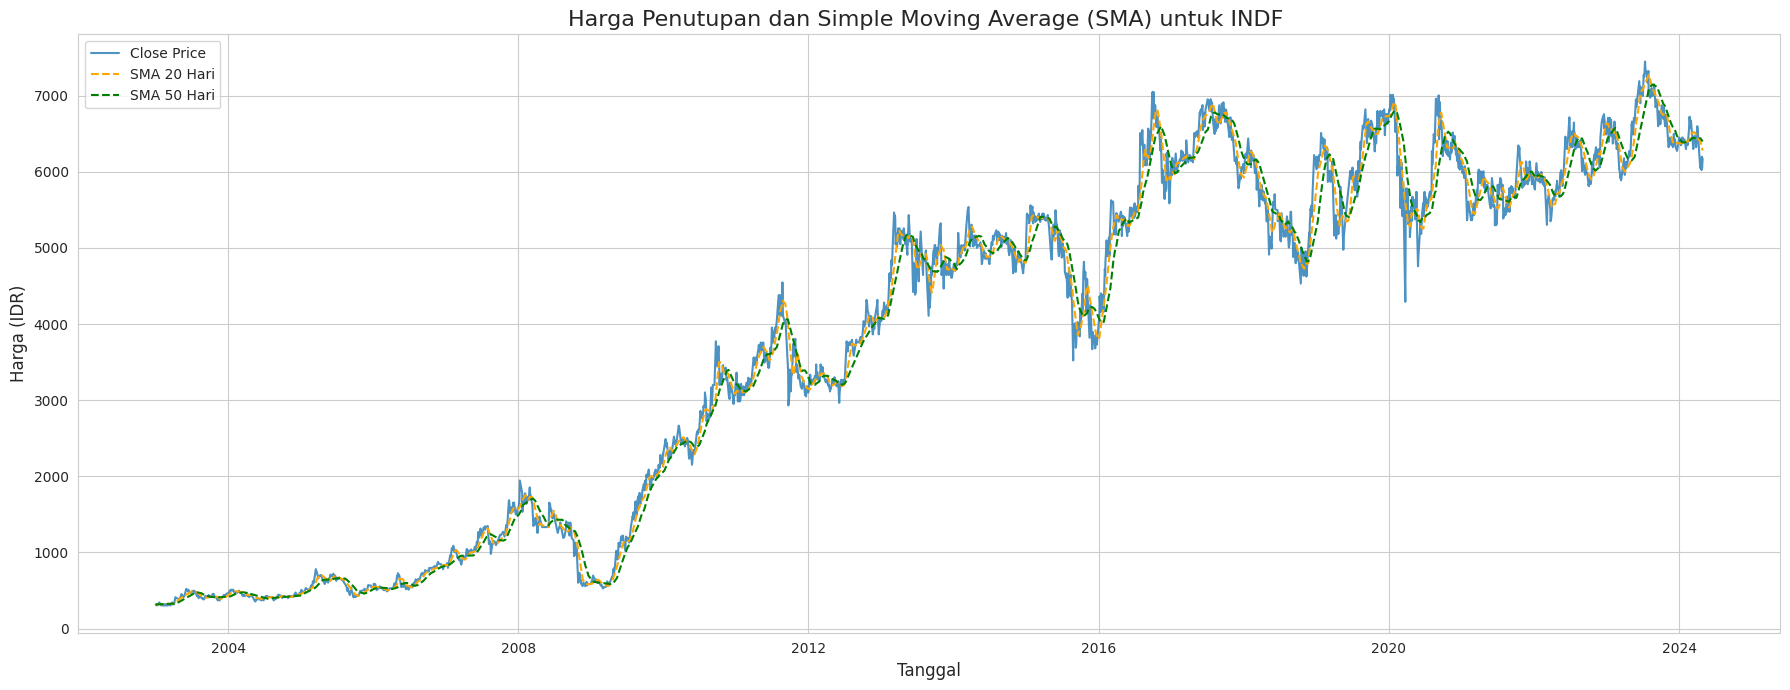

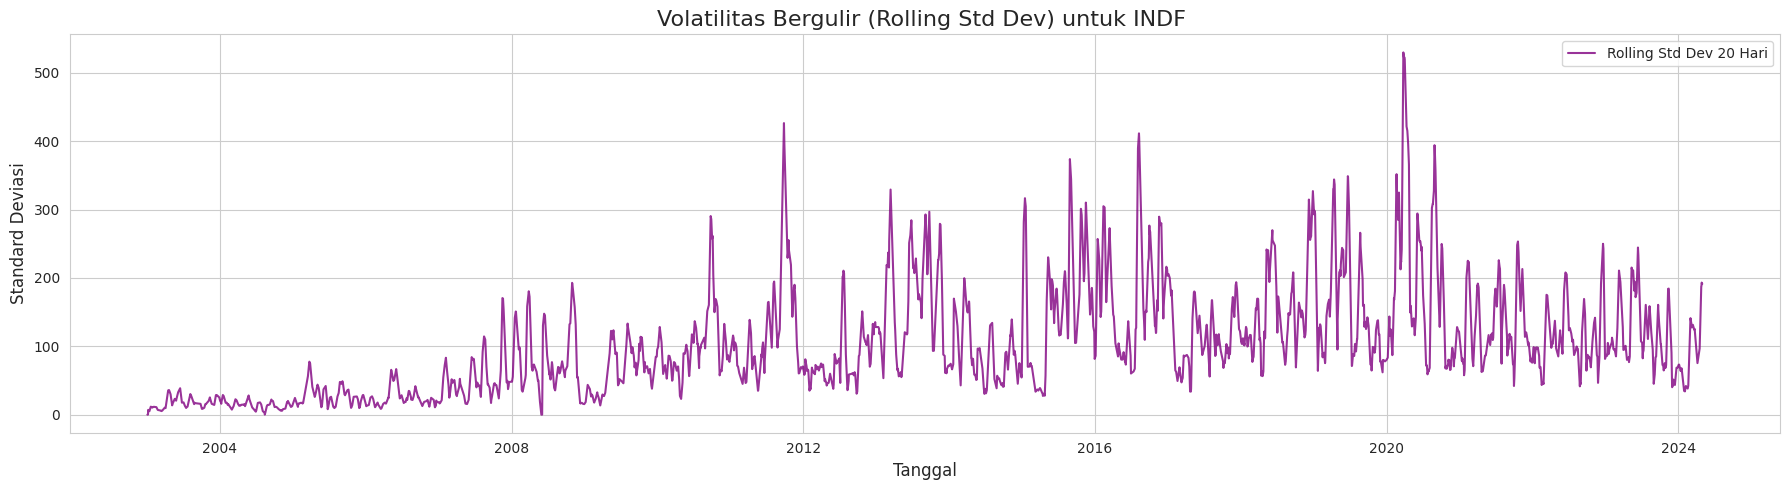

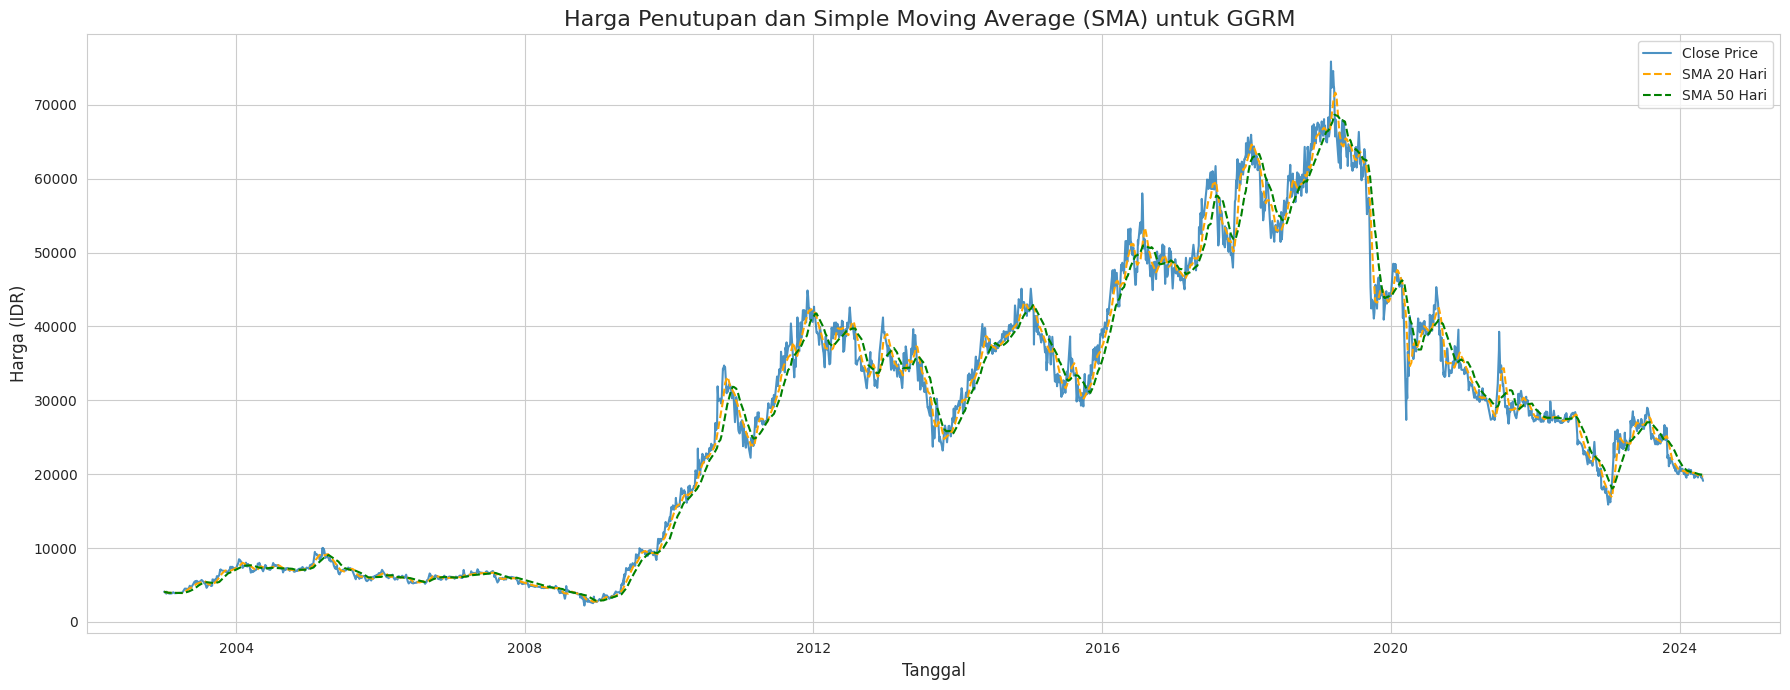

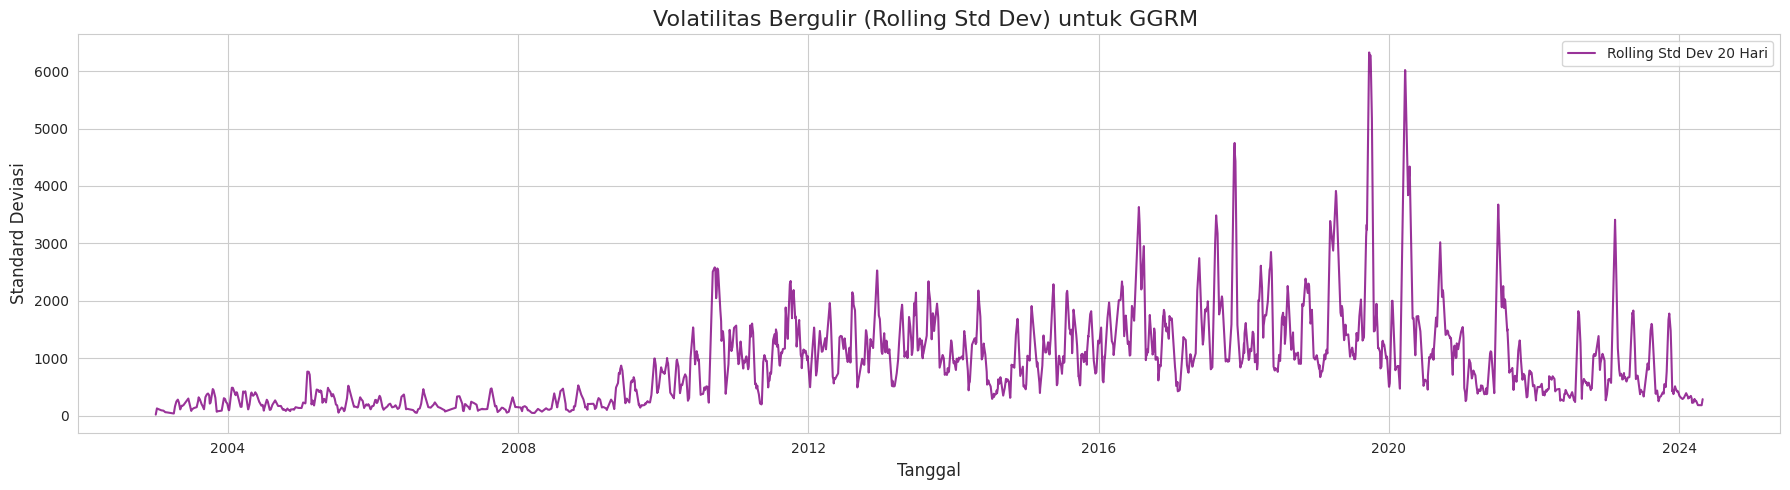

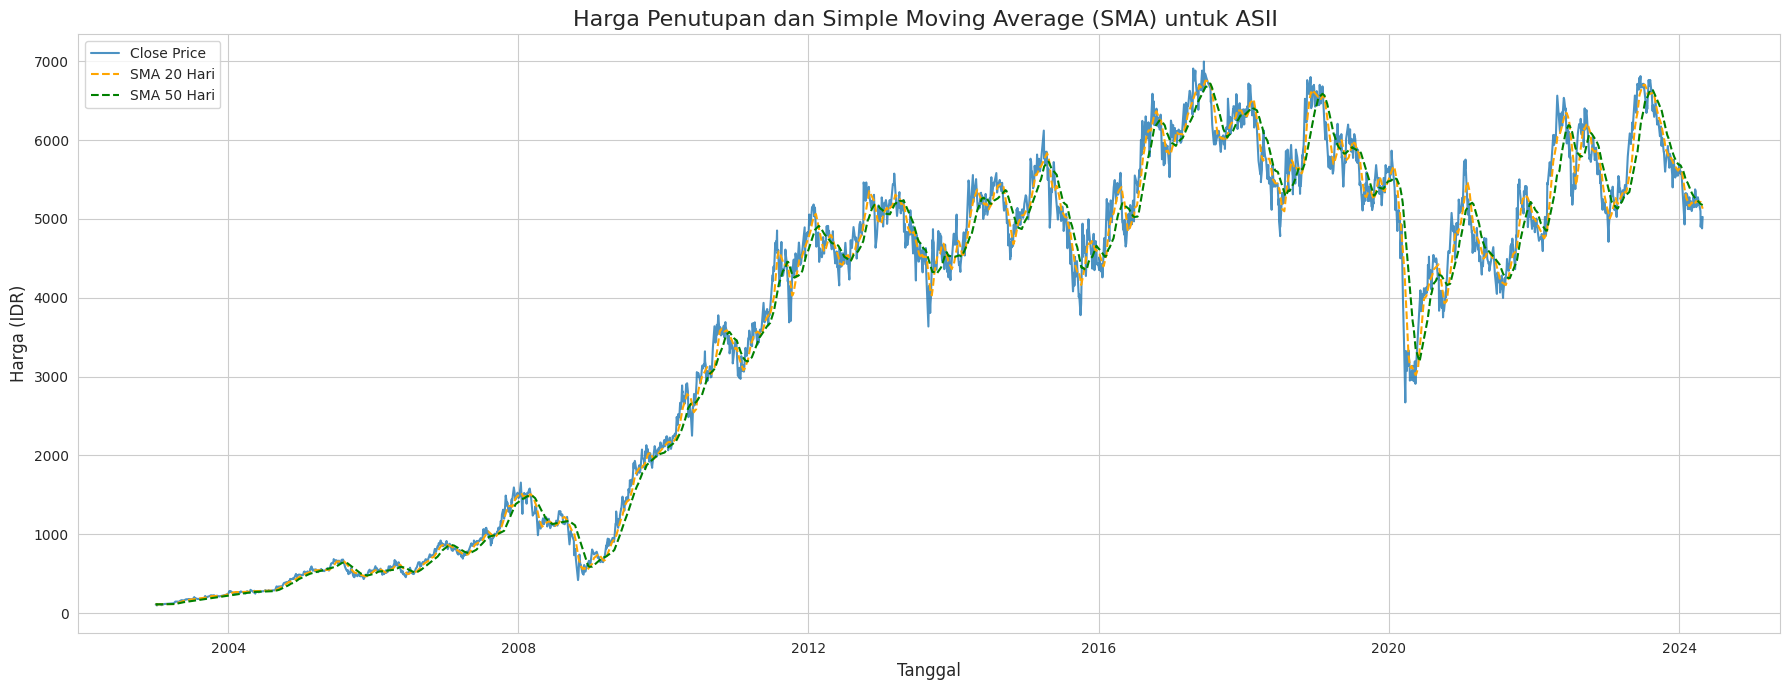

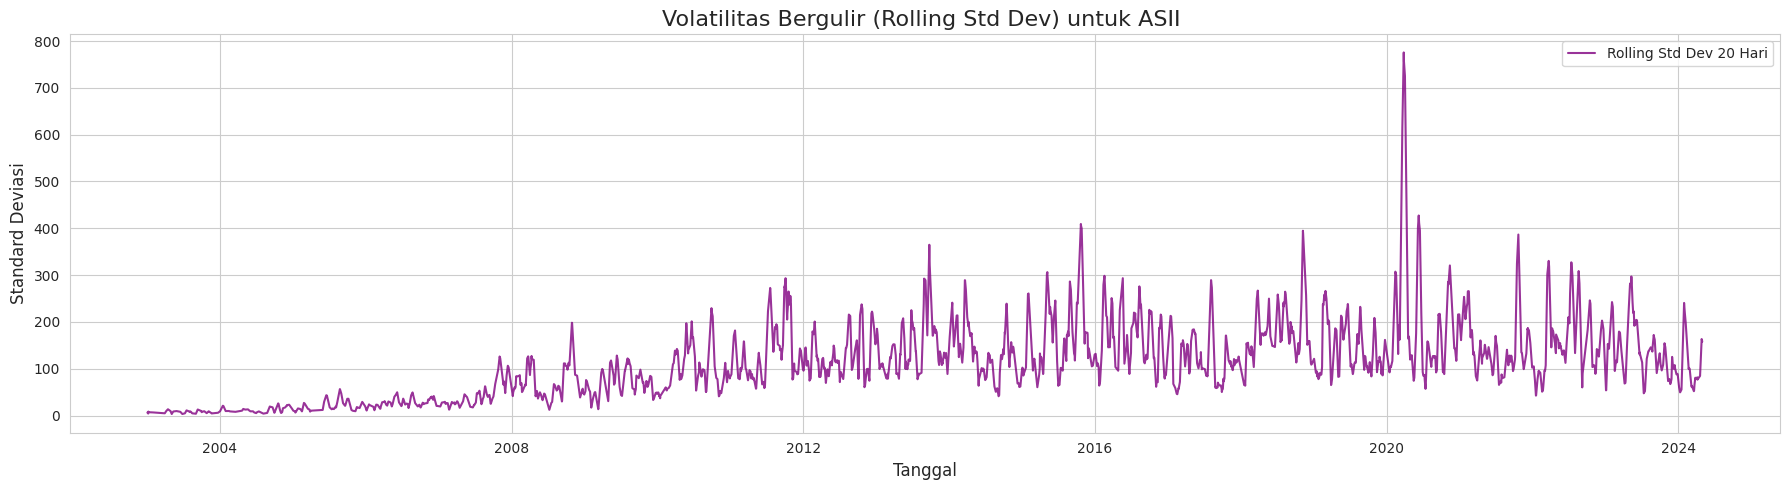

Analisis rolling statistics selesai.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')

# Pilih beberapa saham teratas untuk analisis rolling statistics
top_stocks_for_rolling = df['Stock_Name'].value_counts().head(3).index.tolist()

window_size_short = 20 # Misalnya, 20 hari perdagangan
window_size_long = 50  # Misalnya, 50 hari perdagangan

print(f"Melakukan analisis Rolling Statistics untuk saham: {top_stocks_for_rolling}\n")

for stock in top_stocks_for_rolling:
    # Pastikan data diurutkan berdasarkan tanggal untuk perhitungan rolling yang benar
    stock_df = df[df['Stock_Name'] == stock].sort_values(by='Date').set_index('Date').copy()

    # Calculate Simple Moving Average (SMA)
    stock_df['SMA_20'] = stock_df['Close'].rolling(window=window_size_short, min_periods=1).mean()
    stock_df['SMA_50'] = stock_df['Close'].rolling(window=window_size_long, min_periods=1).mean()

    # Calculate Rolling Standard Deviation (Volatility)
    stock_df['Rolling_Std_20'] = stock_df['Close'].rolling(window=window_size_short, min_periods=1).std()

    # Plot Rolling Mean
    plt.figure(figsize=(18, 7))
    plt.plot(stock_df['Close'], label='Close Price', alpha=0.8)
    plt.plot(stock_df['SMA_20'], label=f'SMA {window_size_short} Hari', color='orange', linestyle='--')
    plt.plot(stock_df['SMA_50'], label=f'SMA {window_size_long} Hari', color='green', linestyle='--')
    plt.title(f'Harga Penutupan dan Simple Moving Average (SMA) untuk {stock}', fontsize=16)
    plt.xlabel('Tanggal', fontsize=12)
    plt.ylabel('Harga (IDR)', fontsize=12)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # Plot Rolling Standard Deviation
    plt.figure(figsize=(18, 5))
    plt.plot(stock_df['Rolling_Std_20'], label=f'Rolling Std Dev {window_size_short} Hari', color='purple', alpha=0.8)
    plt.title(f'Volatilitas Bergulir (Rolling Std Dev) untuk {stock}', fontsize=16)
    plt.xlabel('Tanggal', fontsize=12)
    plt.ylabel('Standard Deviasi', fontsize=12)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

print('Analisis rolling statistics selesai.')

## 6. Analisis Musiman & Pola Berulang (The Patterns)



### 6.1 Day-of-the-Week Effect



/tmp/ipykernel_323/2366517423.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Day_Name', y='Daily_Return', data=daily_avg, ax=axes[0], palette='viridis')
/tmp/ipykernel_323/2366517423.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Day_Name', y='Volume', data=daily_avg, ax=axes[1], palette='viridis')


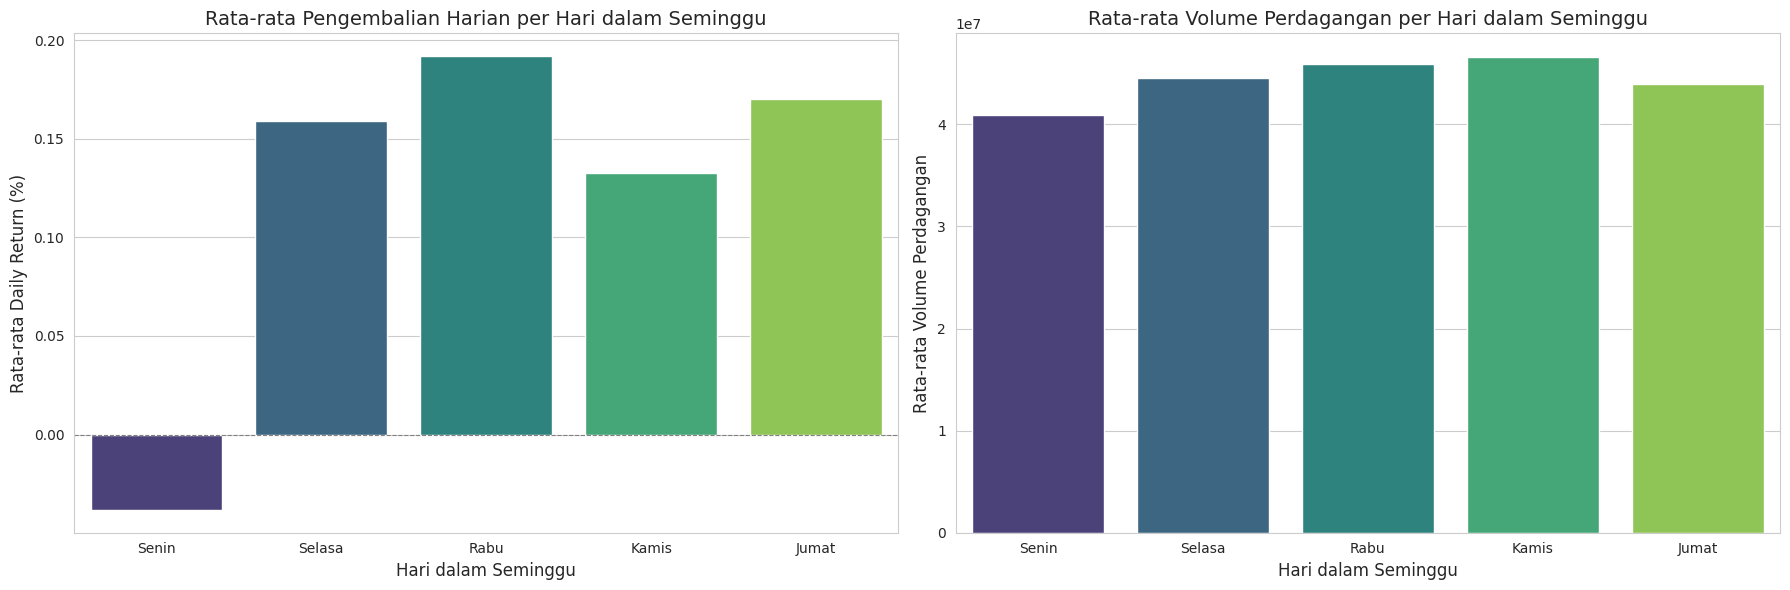

Analisis efek hari dalam seminggu selesai.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')

# Pastikan kolom 'Daily_Return' sudah ada. Jika belum, hitung ulang.
if 'Daily_Return' not in df.columns:
    df_temp_sorted = df.sort_values(by=['Stock_Name', 'Date'])
    df_temp_sorted['Daily_Return'] = df_temp_sorted.groupby('Stock_Name')['Close'].pct_change() * 100
    df = df_temp_sorted # Update df dengan Daily_Return yang baru

daily_avg = df.groupby('Day_of_Week')[['Daily_Return', 'Volume']].mean().reset_index()

# Map Day_of_Week ke nama hari untuk keterbacaan yang lebih baik
day_names = ['Senin', 'Selasa', 'Rabu', 'Kamis', 'Jumat', 'Sabtu', 'Minggu']
daily_avg['Day_Name'] = daily_avg['Day_of_Week'].map(lambda x: day_names[x])

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.barplot(x='Day_Name', y='Daily_Return', data=daily_avg, ax=axes[0], palette='viridis')
axes[0].set_title('Rata-rata Pengembalian Harian per Hari dalam Seminggu', fontsize=14)
axes[0].set_xlabel('Hari dalam Seminggu', fontsize=12)
axes[0].set_ylabel('Rata-rata Daily Return (%)', fontsize=12)
axes[0].axhline(0, color='gray', linestyle='--', linewidth=0.8) # Garis nol untuk referensi

sns.barplot(x='Day_Name', y='Volume', data=daily_avg, ax=axes[1], palette='viridis')
axes[1].set_title('Rata-rata Volume Perdagangan per Hari dalam Seminggu', fontsize=14)
axes[1].set_xlabel('Hari dalam Seminggu', fontsize=12)
axes[1].set_ylabel('Rata-rata Volume Perdagangan', fontsize=12)

plt.tight_layout()
plt.show()

print('Analisis efek hari dalam seminggu selesai.')

### 6.2 Analisis Pola Bulanan (Monthly Seasonality)




Analisis Pola Bulanan (Rata-rata Harga Penutupan dan Volume):



/tmp/ipykernel_323/784332545.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Month', y='Close', data=monthly_avg, ax=axes[0], palette='coolwarm')
/tmp/ipykernel_323/784332545.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Month', y='Volume', data=monthly_avg, ax=axes[1], palette='coolwarm')


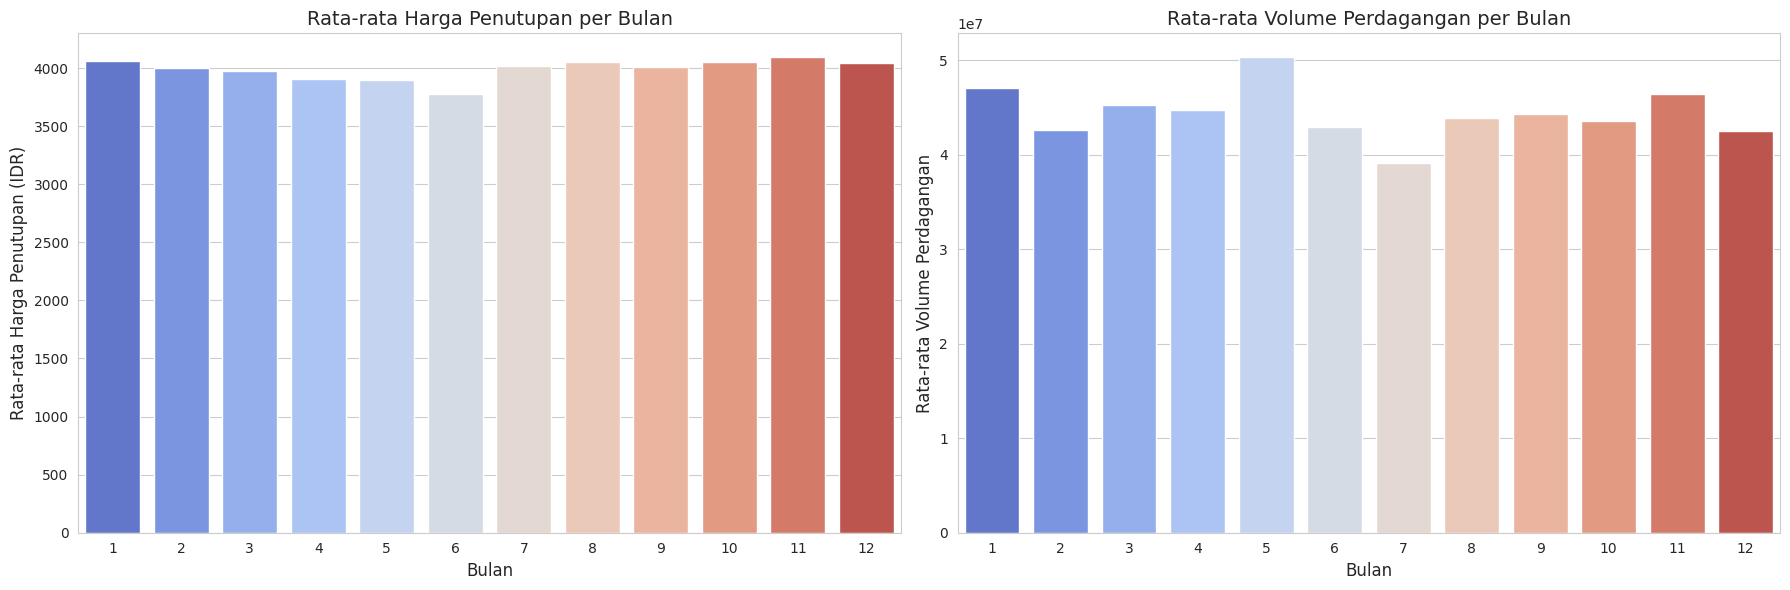

Analisis pola bulanan selesai.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')

# Analisis Pola Bulanan (Rata-rata Harga Penutupan dan Volume)
print("\nAnalisis Pola Bulanan (Rata-rata Harga Penutupan dan Volume):\n")
monthly_avg = df.groupby('Month')[['Close', 'Volume']].mean().reset_index()

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
sns.barplot(x='Month', y='Close', data=monthly_avg, ax=axes[0], palette='coolwarm')
axes[0].set_title('Rata-rata Harga Penutupan per Bulan', fontsize=14)
axes[0].set_xlabel('Bulan', fontsize=12)
axes[0].set_ylabel('Rata-rata Harga Penutupan (IDR)', fontsize=12)

sns.barplot(x='Month', y='Volume', data=monthly_avg, ax=axes[1], palette='coolwarm')
axes[1].set_title('Rata-rata Volume Perdagangan per Bulan', fontsize=14)
axes[1].set_xlabel('Bulan', fontsize=12)
axes[1].set_ylabel('Rata-rata Volume Perdagangan', fontsize=12)
plt.tight_layout()
plt.show()

print('Analisis pola bulanan selesai.')

## 7. Analisis Pengembalian (Financial Return Analysis)



### 7.1 Kalkulasi Log Returns



In [ ]:
import numpy as np
import pandas as pd

# Pastikan DataFrame diurutkan berdasarkan Stock_Name dan Date
df_sorted = df.sort_values(by=['Stock_Name', 'Date']).copy()

# Hitung Daily Return (simple return dalam persentase) untuk setiap saham
df_sorted['Daily_Return'] = df_sorted.groupby('Stock_Name')['Close'].pct_change() * 100

# Hitung Log Returns untuk setiap saham
df_sorted['Log_Return'] = df_sorted.groupby('Stock_Name')['Close'].transform(lambda x: np.log(x / x.shift(1)))

print('5 baris pertama dengan Daily_Return dan Log_Return:')
print(df_sorted.head())
print('\n')

print('Statistik Deskriptif untuk Daily_Return:')
print(df_sorted['Daily_Return'].describe())
print('\n')

print('Statistik Deskriptif untuk Log_Return:')
print(df_sorted['Log_Return'].describe())
print('\n')

df = df_sorted.copy() # Update the main DataFrame with new features
print('Kalkulasi Daily Return dan Log Return selesai.')

5 baris pertama dengan Daily_Return dan Log_Return:
  Stock_Name       Date  Open  High  Low  Close      Volume  Year  Month  Day  \
0      ACES  2007-11-06    75    78   68     75  1274430000  2007     11    6   
1      ACES  2007-11-07    75    79   74     77   349330000  2007     11    7   
2      ACES  2007-11-08    76    76   73     76    66270000  2007     11    8   
3      ACES  2007-11-09    73    74   73     73    40075000  2007     11    9   
4      ACES  2007-11-12    69    73   68     69   113285000  2007     11   12   

   ...  Quarter  Is_Month_Start  Is_Month_End  Is_Quarter_Start  \
0  ...        4               0             0                 0   
1  ...        4               0             0                 0   
2  ...        4               0             0                 0   
3  ...        4               0             0                 0   
4  ...        4               0             0                 0   

   Is_Quarter_End  Is_Year_Start  Is_Year_End  Is_Weekend 

### 7.2 Distribusi Returns



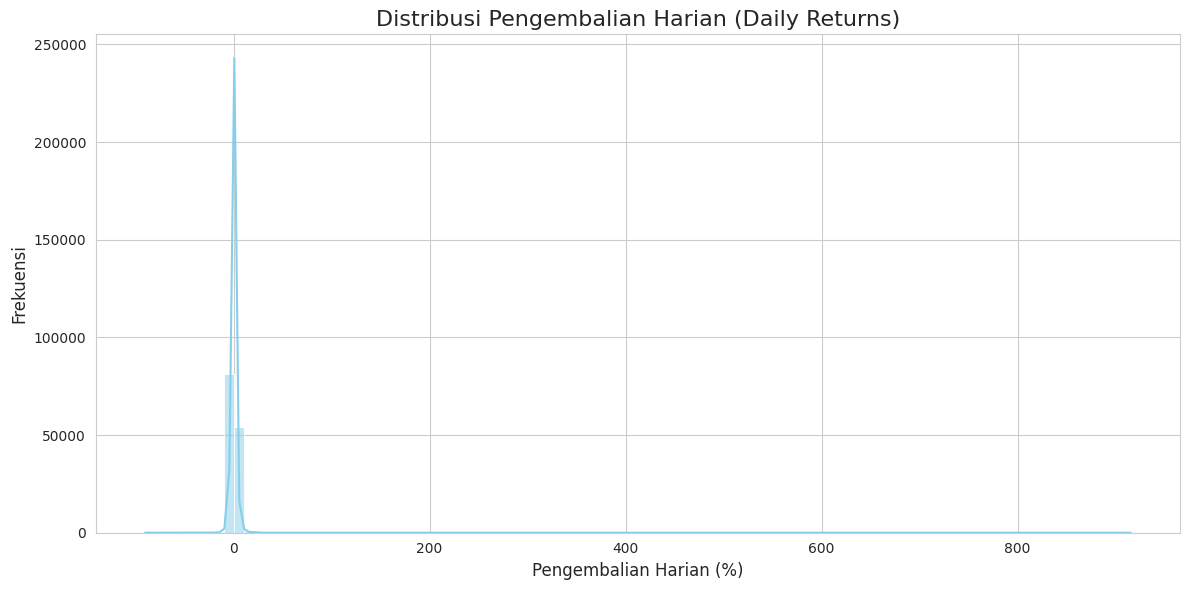

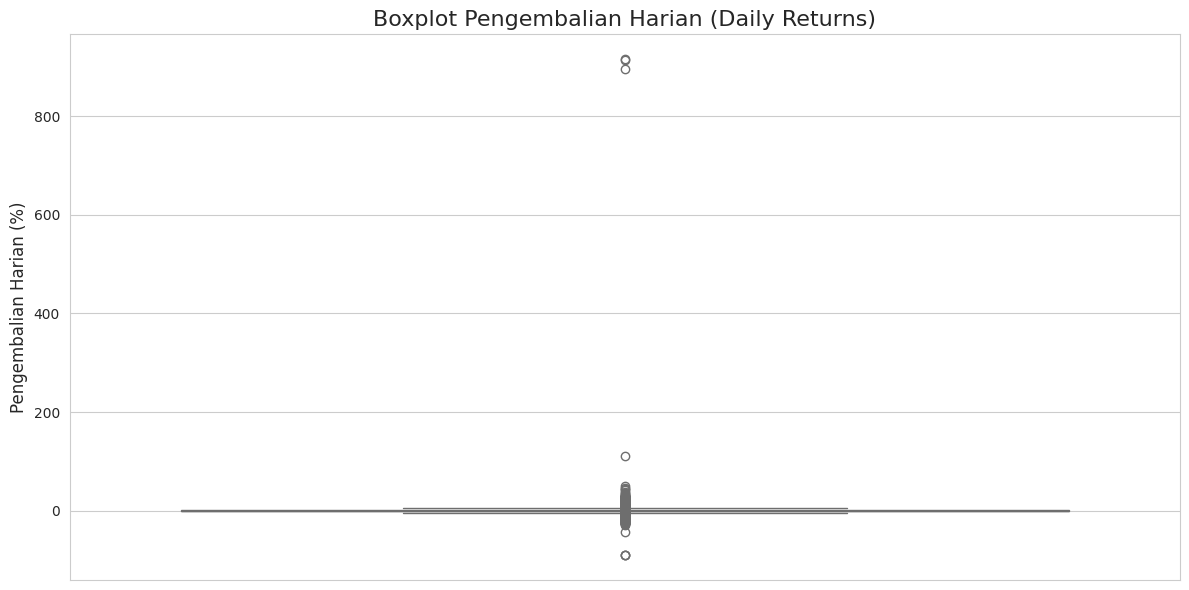

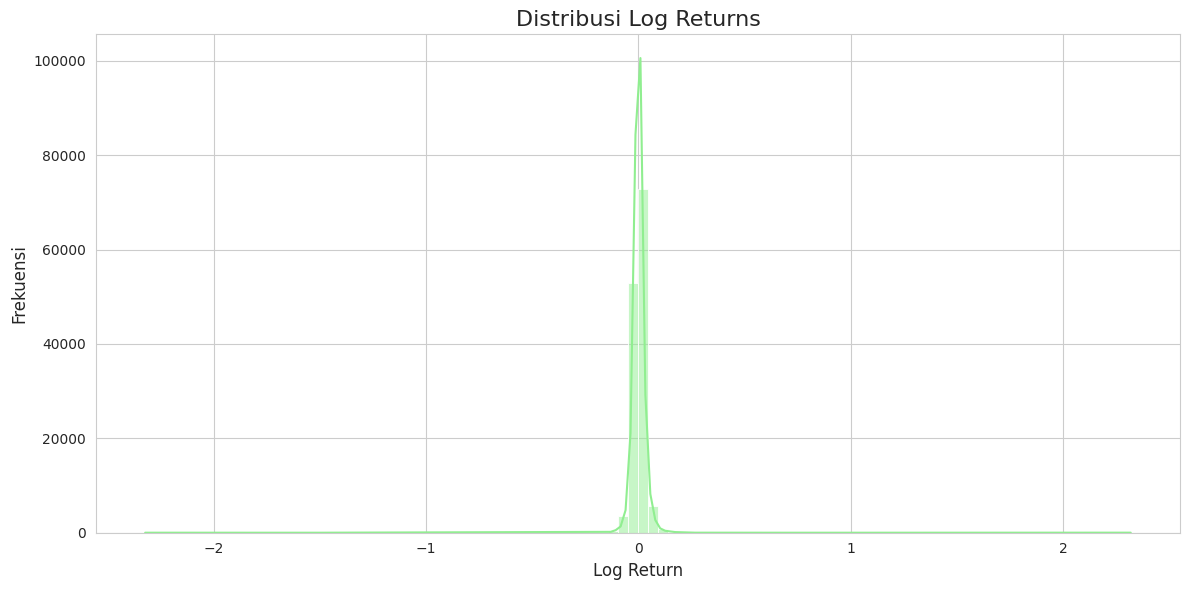

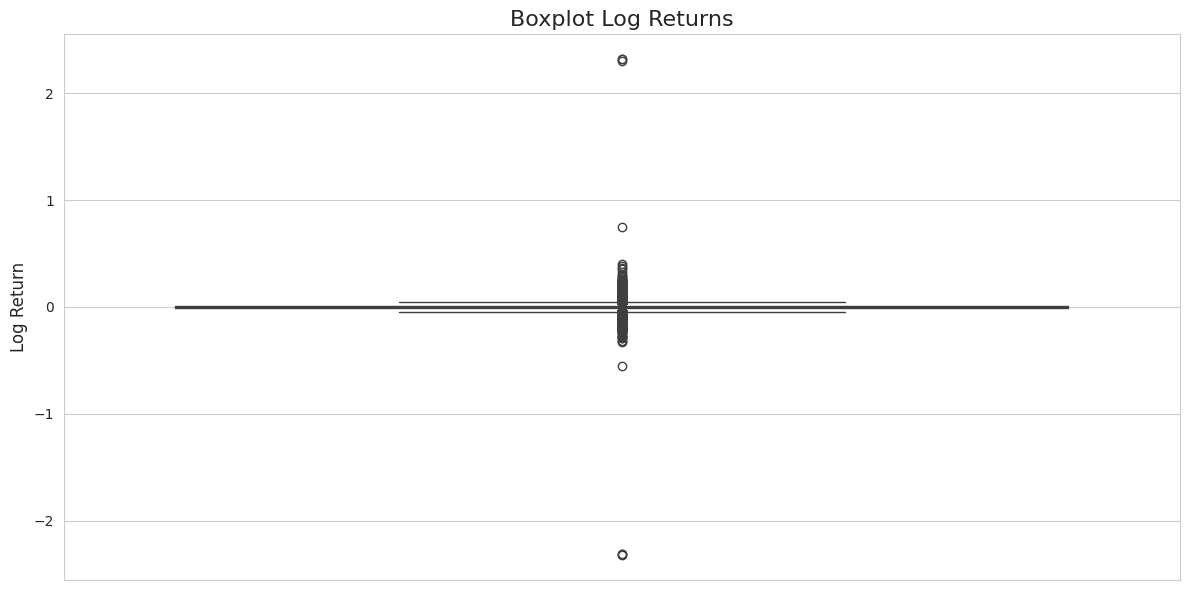

Visualisasi distribusi returns selesai.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')

# Visualisasi Distribusi Daily_Return
plt.figure(figsize=(12, 6))
sns.histplot(df['Daily_Return'].dropna(), bins=100, kde=True, color='skyblue')
plt.title('Distribusi Pengembalian Harian (Daily Returns)', fontsize=16)
plt.xlabel('Pengembalian Harian (%)', fontsize=12)
plt.ylabel('Frekuensi', fontsize=12)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))
sns.boxplot(y=df['Daily_Return'].dropna(), color='lightcoral')
plt.title('Boxplot Pengembalian Harian (Daily Returns)', fontsize=16)
plt.ylabel('Pengembalian Harian (%)', fontsize=12)
plt.tight_layout()
plt.show()

# Visualisasi Distribusi Log_Return
plt.figure(figsize=(12, 6))
sns.histplot(df['Log_Return'].dropna(), bins=100, kde=True, color='lightgreen')
plt.title('Distribusi Log Returns', fontsize=16)
plt.xlabel('Log Return', fontsize=12)
plt.ylabel('Frekuensi', fontsize=12)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))
sns.boxplot(y=df['Log_Return'].dropna(), color='lightseagreen')
plt.title('Boxplot Log Returns', fontsize=16)
plt.ylabel('Log Return', fontsize=12)
plt.tight_layout()
plt.show()

print('Visualisasi distribusi returns selesai.')

### 7.3 Volatility Clustering



Memvisualisasikan Volatility Clustering untuk saham: ['INDF ', 'GGRM ', 'ASII ']



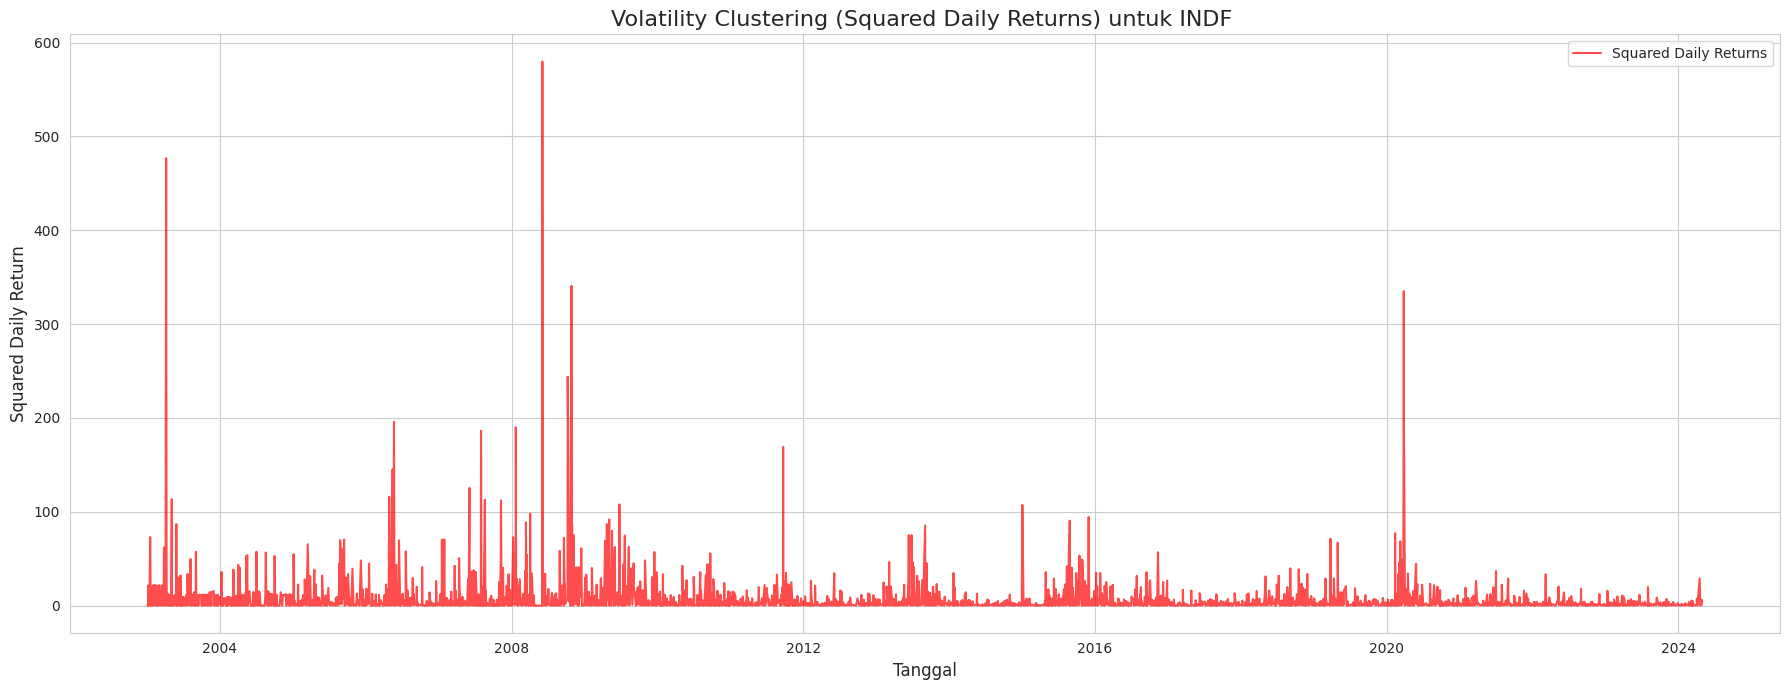

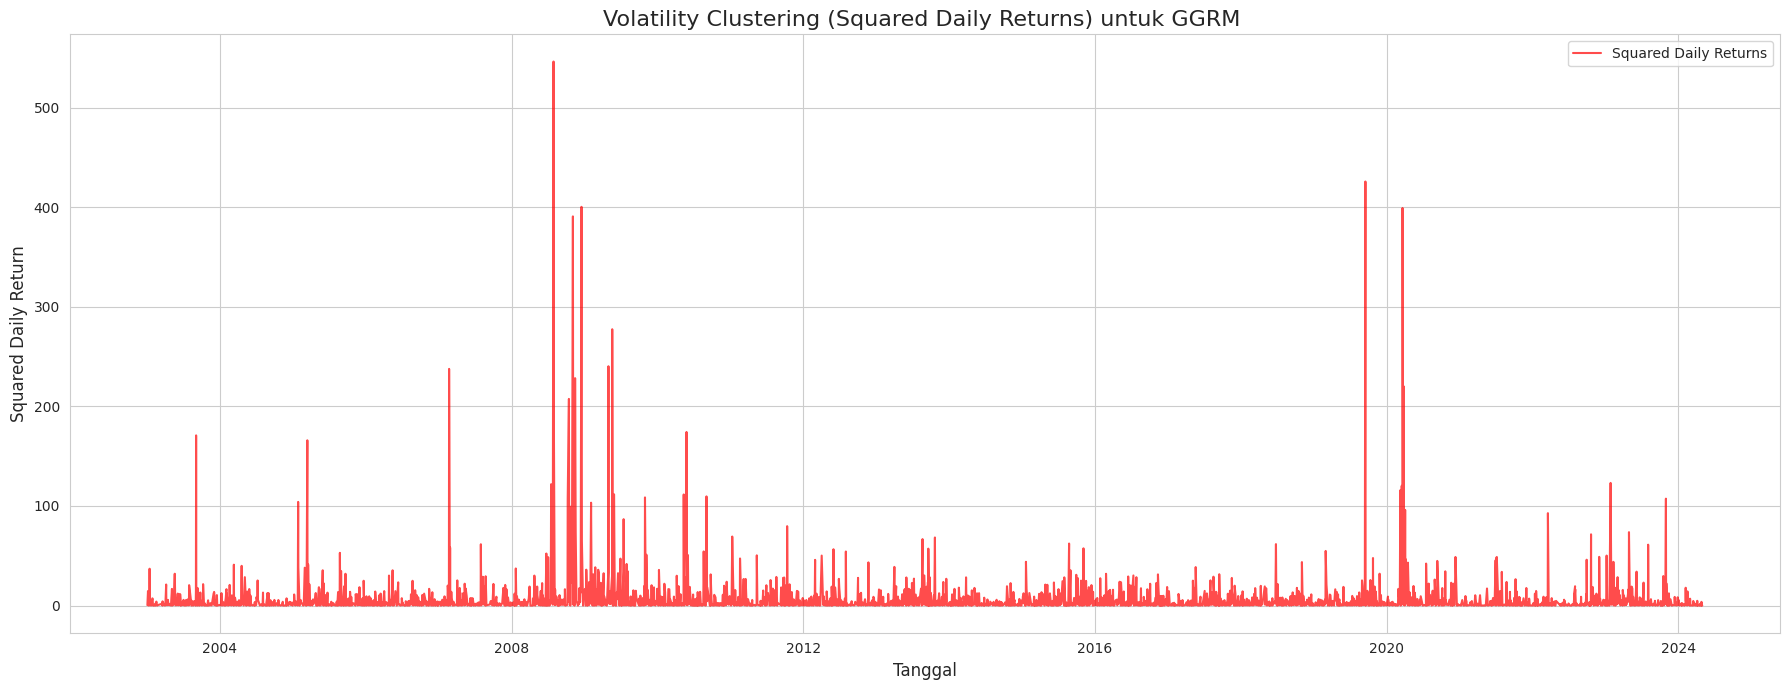

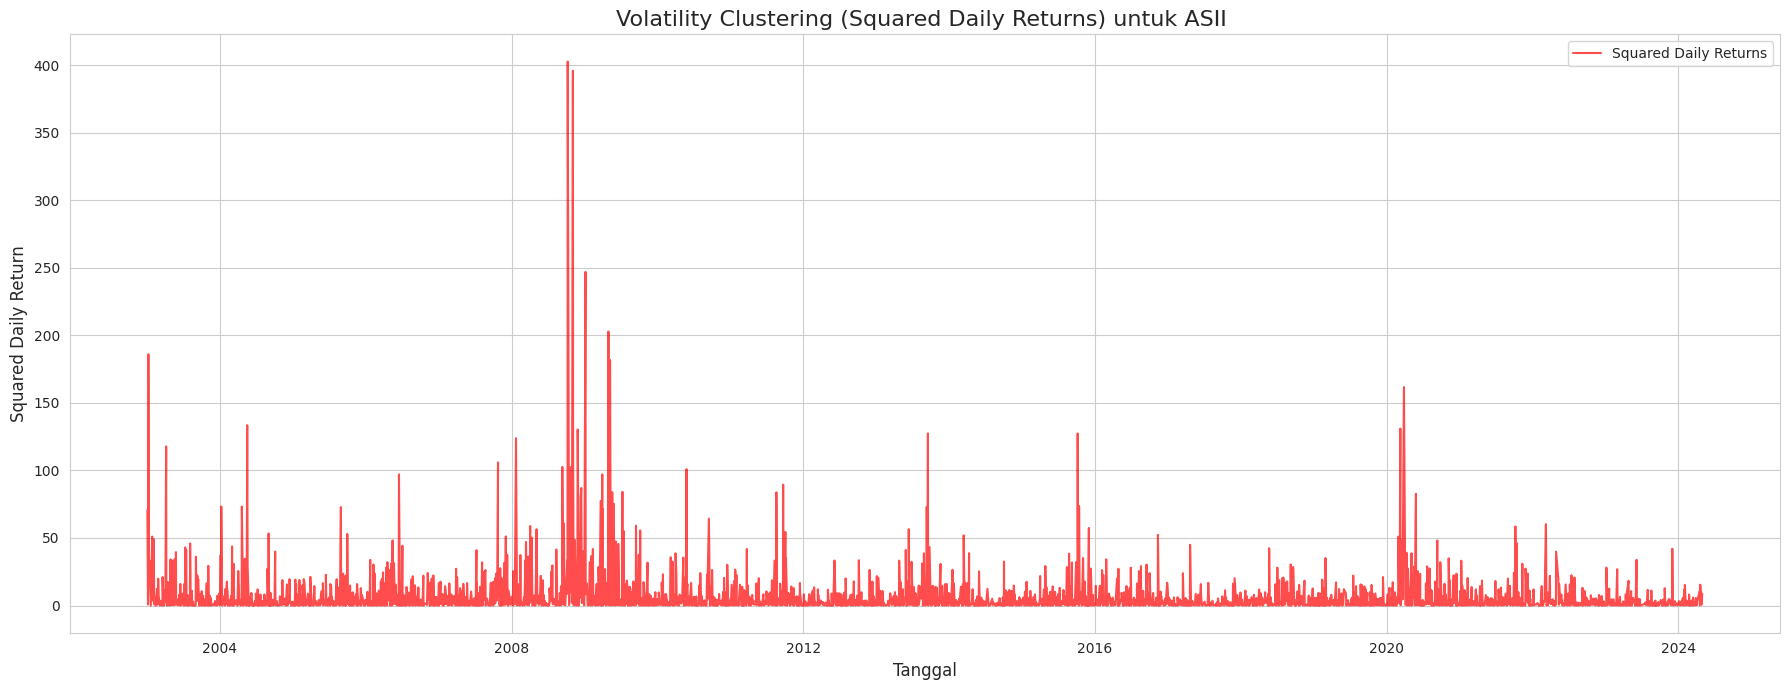

Visualisasi volatility clustering selesai.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')

# Pilih beberapa saham teratas untuk analisis volatility clustering
top_stocks_for_vol_cluster = df['Stock_Name'].value_counts().head(3).index.tolist()

print(f"Memvisualisasikan Volatility Clustering untuk saham: {top_stocks_for_vol_cluster}\n")

for stock in top_stocks_for_vol_cluster:
    stock_df = df[df['Stock_Name'] == stock].set_index('Date').sort_index()

    # Calculate squared daily returns as a proxy for volatility
    stock_df['Squared_Daily_Return'] = stock_df['Daily_Return']**2

    # Plot Squared Daily Returns
    plt.figure(figsize=(18, 7))
    plt.plot(stock_df.index, stock_df['Squared_Daily_Return'], label='Squared Daily Returns', alpha=0.7, color='red')
    plt.title(f'Volatility Clustering (Squared Daily Returns) untuk {stock}', fontsize=16)
    plt.xlabel('Tanggal', fontsize=12)
    plt.ylabel('Squared Daily Return', fontsize=12)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

print('Visualisasi volatility clustering selesai.')

## 8. Diagnostik Deret Waktu Tingkat Lanjut (The "Professor" Level)



### 8.1 Stationarity Test (ADF Test)



In [ ]:
from statsmodels.tsa.stattools import adfuller
import pandas as pd
import numpy as np

# Pilih beberapa saham teratas untuk uji stasioneritas
top_stocks_for_adf = df['Stock_Name'].value_counts().head(3).index.tolist()

print('Melakukan Uji Stasioneritas (Augmented Dickey-Fuller Test) untuk saham:')

for stock in top_stocks_for_adf:
    stock_df = df[df['Stock_Name'] == stock].set_index('Date').sort_index().copy()

    print(f'--- Uji ADF untuk {stock} (Close Price) ---')
    # Hapus NaN jika ada, terutama dari awal deret waktu
    close_price_series = stock_df['Close'].dropna()
    if len(close_price_series) > 0:
        adf_result_close = adfuller(close_price_series)
        print(f'  ADF Statistic: {adf_result_close[0]:.4f}')
        print(f'  p-value: {adf_result_close[1]:.4f}')
        print('  Critical Values:')
        for key, value in adf_result_close[4].items():
            print(f'    {key}: {value:.4f}')
        if adf_result_close[1] <= 0.05:
            print('  Kesimpulan: Deret waktu (Close Price) KEMUNGKINAN stasioner (Tolak H0).')
        else:
            print('  Kesimpulan: Deret waktu (Close Price) KEMUNGKINAN non-stasioner (Gagal Tolak H0).')
    else:
        print('  Data Close Price tidak cukup untuk uji ADF.')

    print(f'--- Uji ADF untuk {stock} (Log Return) ---')
    log_return_series = stock_df['Log_Return'].dropna()
    if len(log_return_series) > 0:
        adf_result_log_return = adfuller(log_return_series)
        print(f'  ADF Statistic: {adf_result_log_return[0]:.4f}')
        print(f'  p-value: {adf_result_log_return[1]:.4f}')
        print('  Critical Values:')
        for key, value in adf_result_log_return[4].items():
            print(f'    {key}: {value:.4f}')
        if adf_result_log_return[1] <= 0.05:
            print('  Kesimpulan: Deret waktu (Log Return) KEMUNGKINAN stasioner (Tolak H0).')
        else:
            print('  Kesimpulan: Deret waktu (Log Return) KEMUNGKINAN non-stasioner (Gagal Tolak H0).')
    else:
        print('  Data Log Return tidak cukup untuk uji ADF.')

print('Uji stasioneritas selesai.')

Melakukan Uji Stasioneritas (Augmented Dickey-Fuller Test) untuk saham:
--- Uji ADF untuk INDF  (Close Price) ---
  ADF Statistic: -1.3183
  p-value: 0.6208
  Critical Values:
    1%: -3.4316
    5%: -2.8621
    10%: -2.5671
  Kesimpulan: Deret waktu (Close Price) KEMUNGKINAN non-stasioner (Gagal Tolak H0).
--- Uji ADF untuk INDF  (Log Return) ---
  ADF Statistic: -15.8556
  p-value: 0.0000
  Critical Values:
    1%: -3.4316
    5%: -2.8621
    10%: -2.5671
  Kesimpulan: Deret waktu (Log Return) KEMUNGKINAN stasioner (Tolak H0).
--- Uji ADF untuk GGRM  (Close Price) ---
  ADF Statistic: -1.5363
  p-value: 0.5155
  Critical Values:
    1%: -3.4316
    5%: -2.8621
    10%: -2.5671
  Kesimpulan: Deret waktu (Close Price) KEMUNGKINAN non-stasioner (Gagal Tolak H0).
--- Uji ADF untuk GGRM  (Log Return) ---
  ADF Statistic: -25.3977
  p-value: 0.0000
  Critical Values:
    1%: -3.4316
    5%: -2.8621
    10%: -2.5671
  Kesimpulan: Deret waktu (Log Return) KEMUNGKINAN stasioner (Tolak H0).
--

### 8.2 Autocorrelation (ACF & PACF)



Melakukan Analisis Autokorelasi (ACF & PACF) untuk saham:


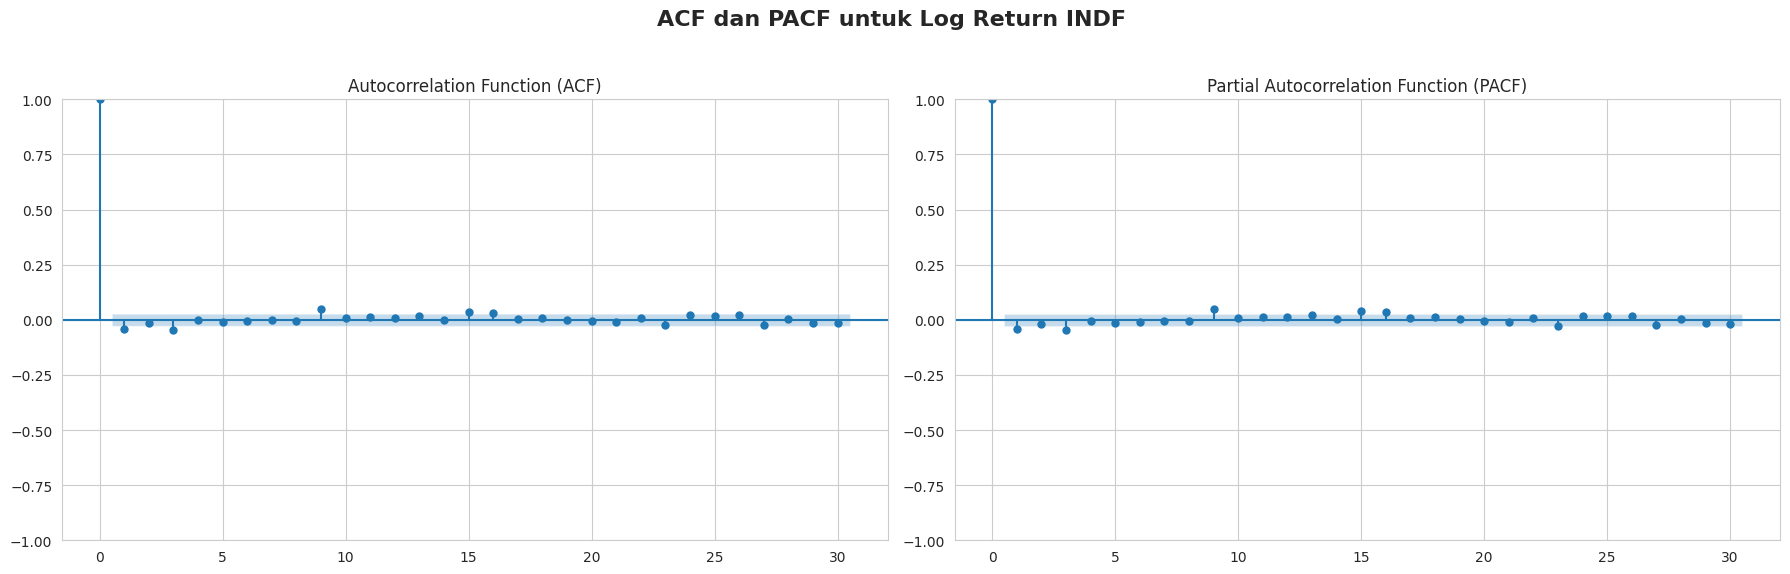

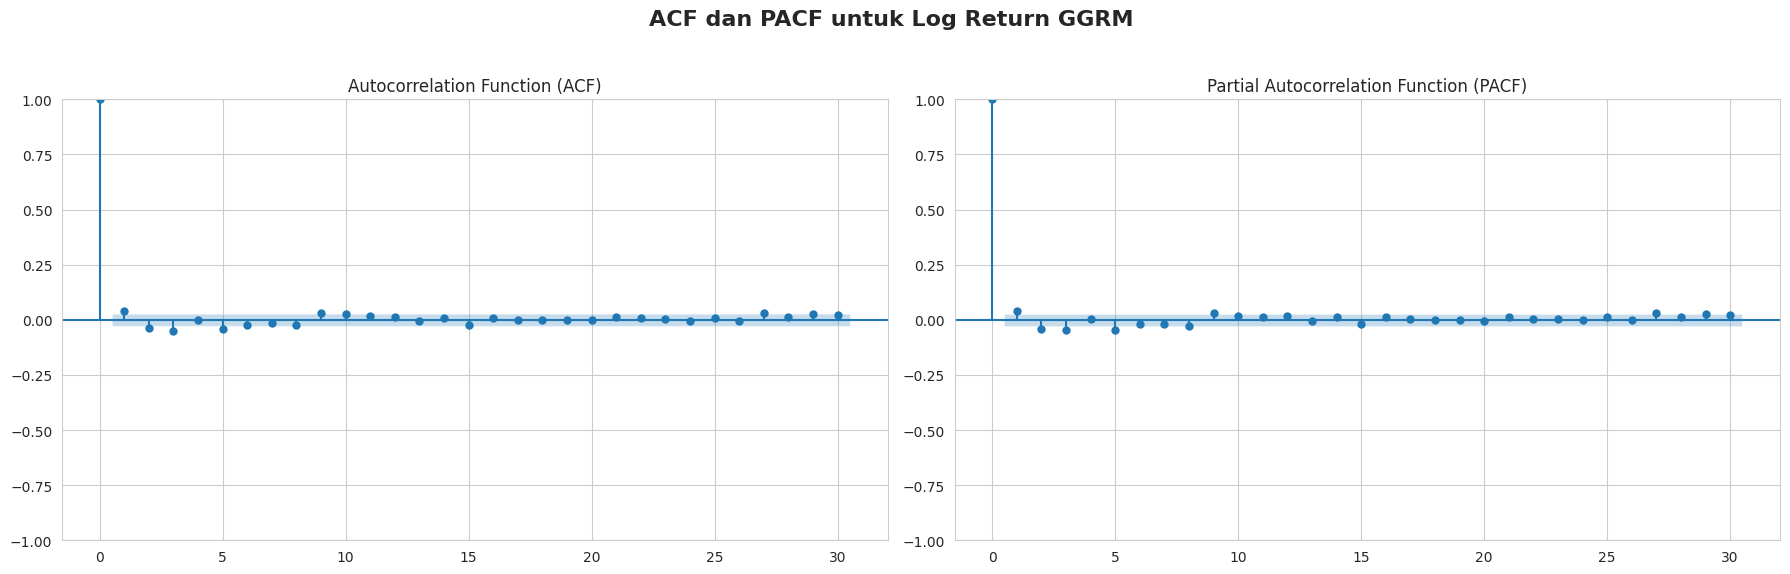

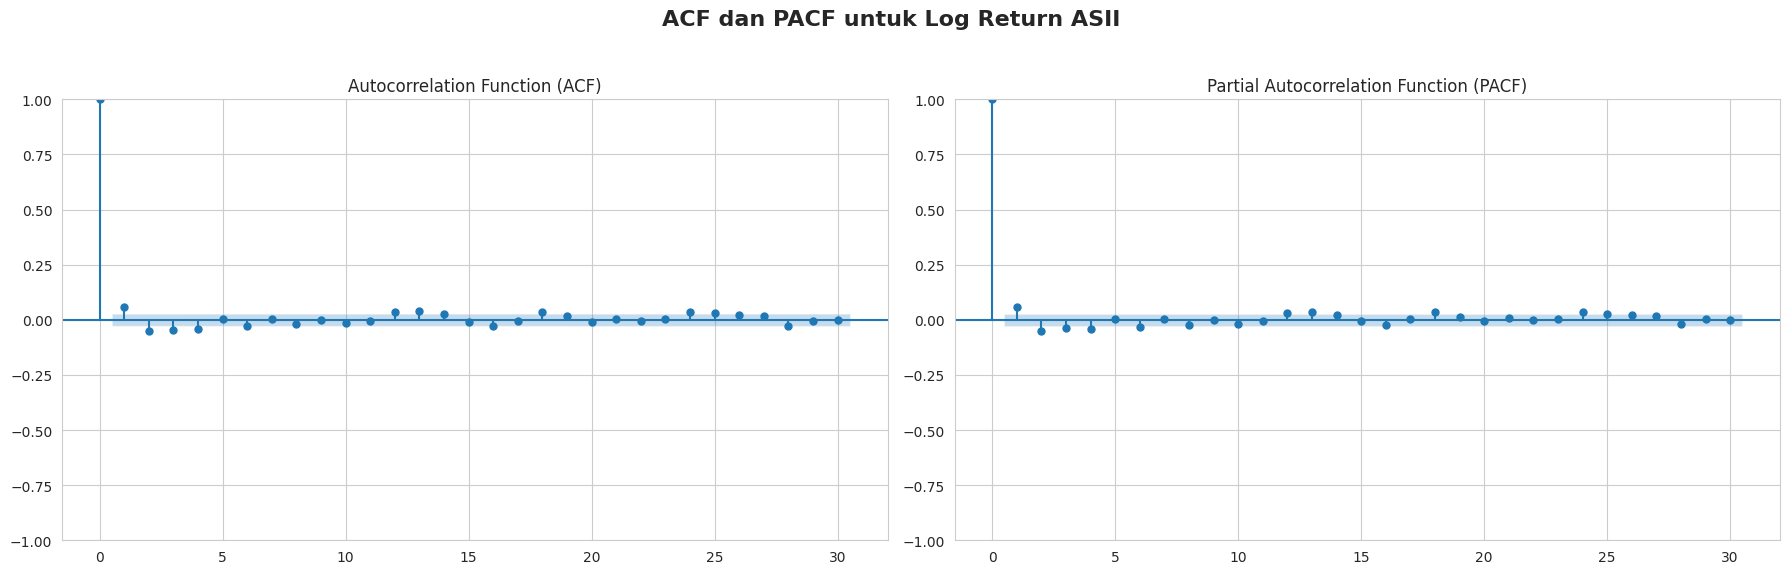

Analisis Autokorelasi (ACF & PACF) selesai.


In [ ]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')

# Pilih beberapa saham teratas untuk analisis ACF/PACF
top_stocks_for_acf_pacf = df['Stock_Name'].value_counts().head(3).index.tolist()

print('Melakukan Analisis Autokorelasi (ACF & PACF) untuk saham:')

for stock in top_stocks_for_acf_pacf:
    stock_df = df[df['Stock_Name'] == stock].set_index('Date').sort_index().copy()

    # Gunakan Log_Return karena diharapkan stasioner
    log_return_series = stock_df['Log_Return'].dropna()

    if len(log_return_series) > 1:
        fig, axes = plt.subplots(1, 2, figsize=(18, 6))
        fig.suptitle(f'ACF dan PACF untuk Log Return {stock}', fontsize=16)

        # Plot ACF
        plot_acf(log_return_series, lags=30, ax=axes[0])
        axes[0].set_title('Autocorrelation Function (ACF)')

        # Plot PACF
        plot_pacf(log_return_series, lags=30, ax=axes[1])
        axes[1].set_title('Partial Autocorrelation Function (PACF)')

        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        plt.show()
    else:
        print(f'  Data Log Return tidak cukup untuk analisis ACF/PACF untuk {stock}.')

print('Analisis Autokorelasi (ACF & PACF) selesai.')

### 8.3 Seasonal Decomposition



Melakukan Dekomposisi Musiman (Seasonal Decomposition) untuk saham:


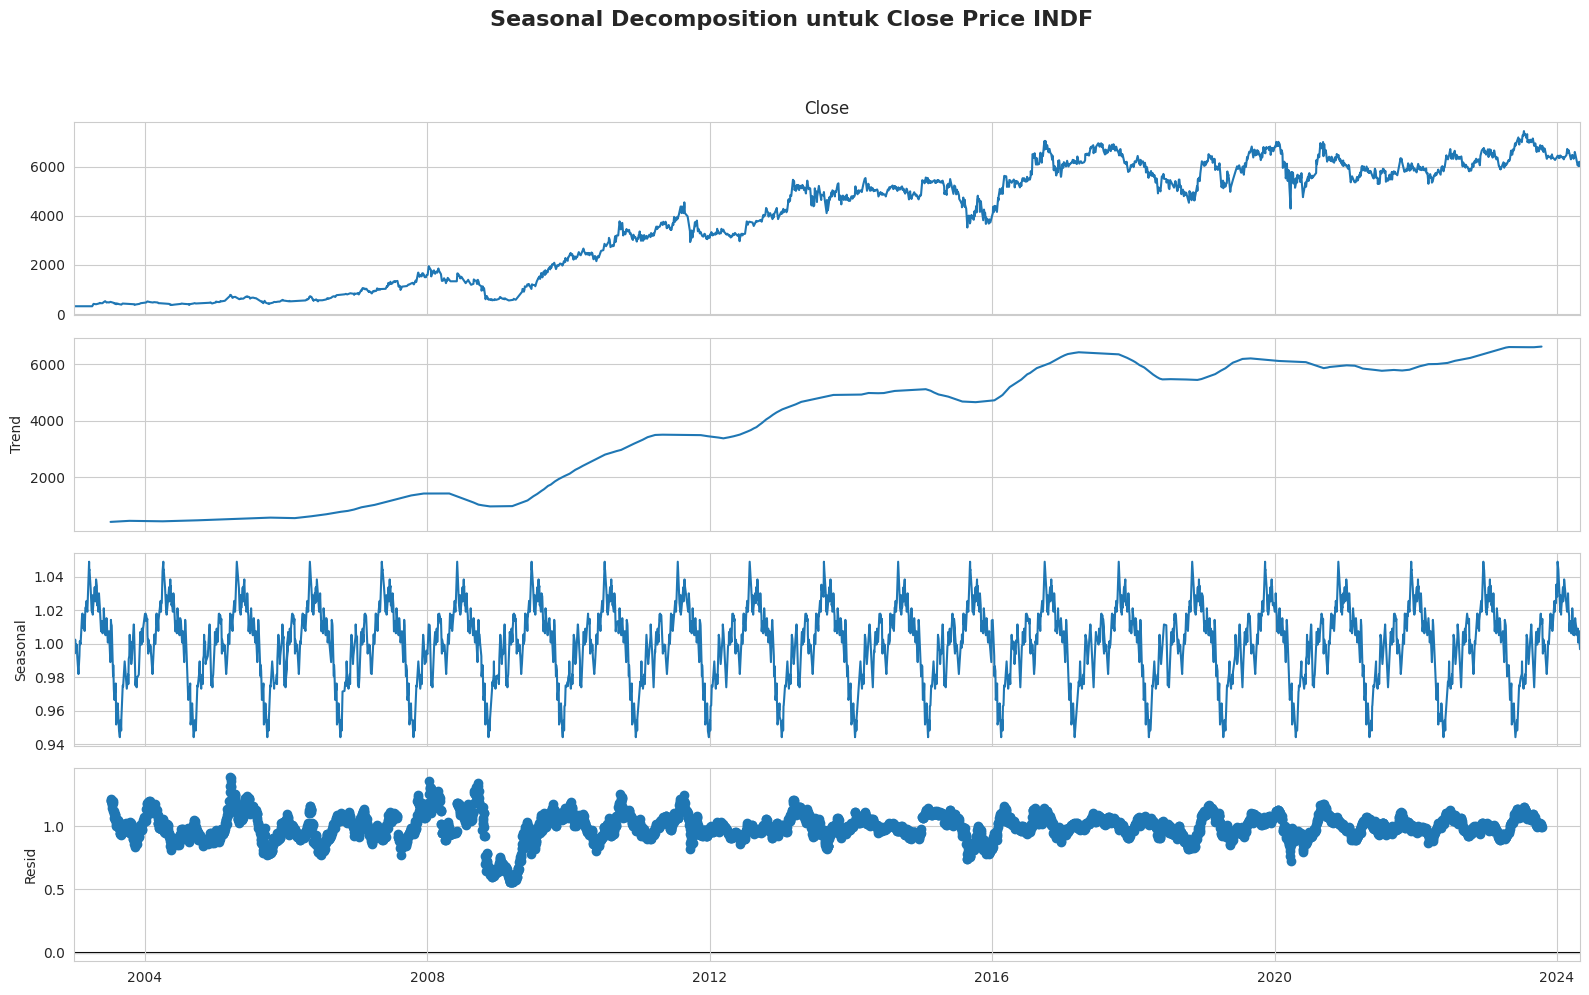

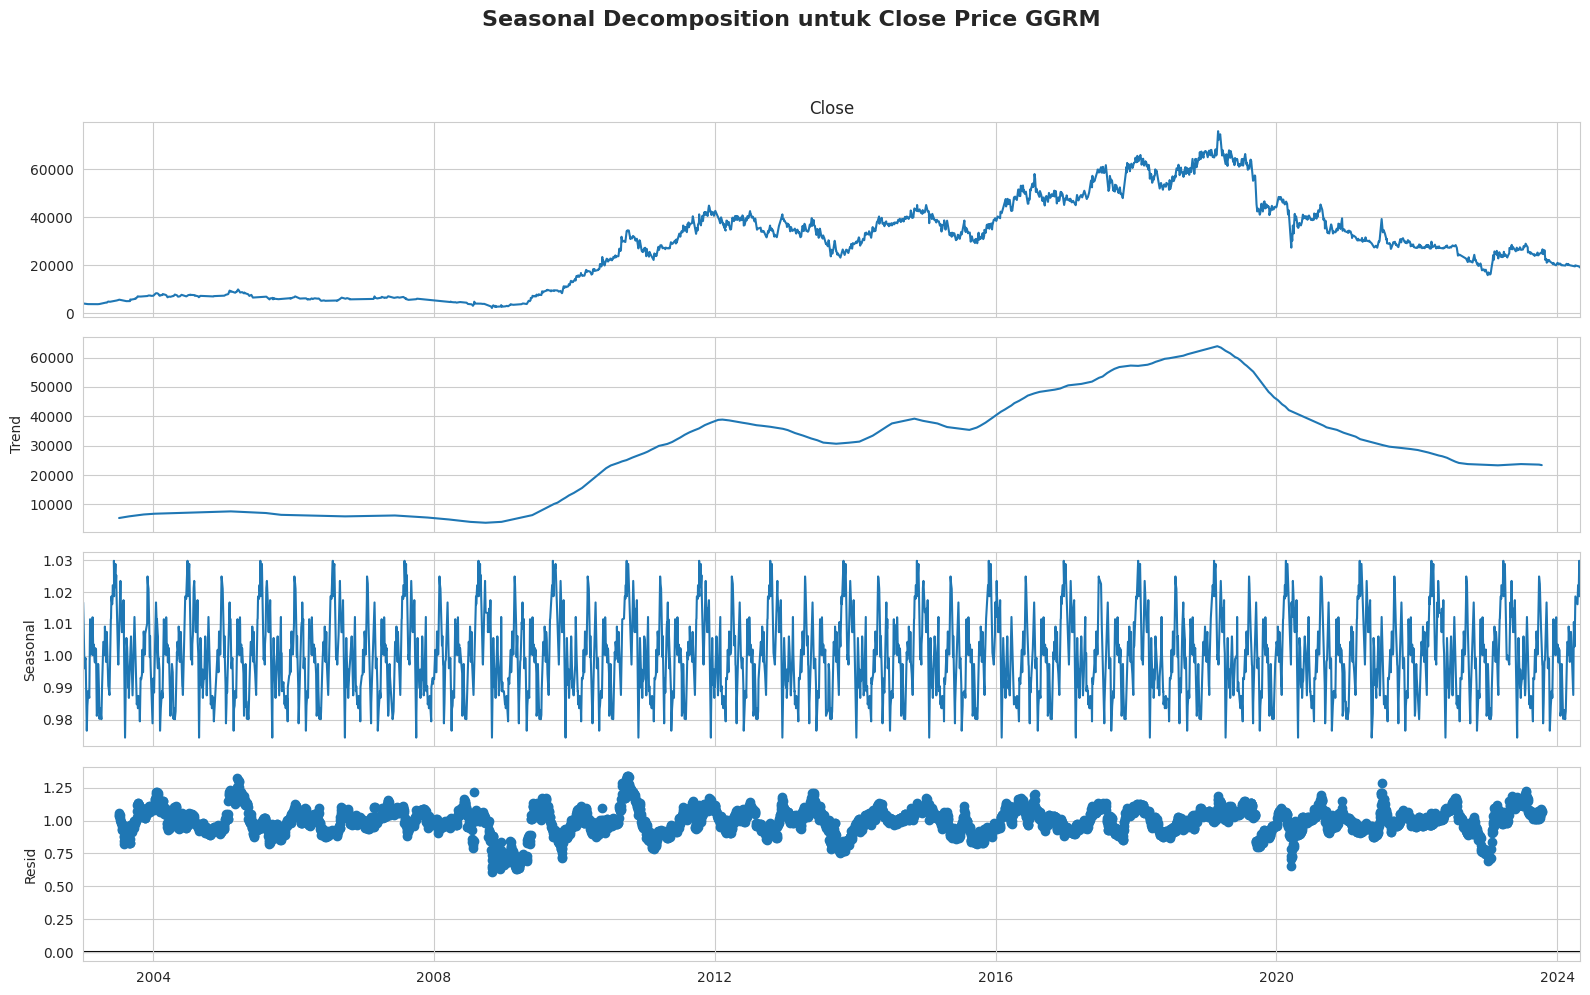

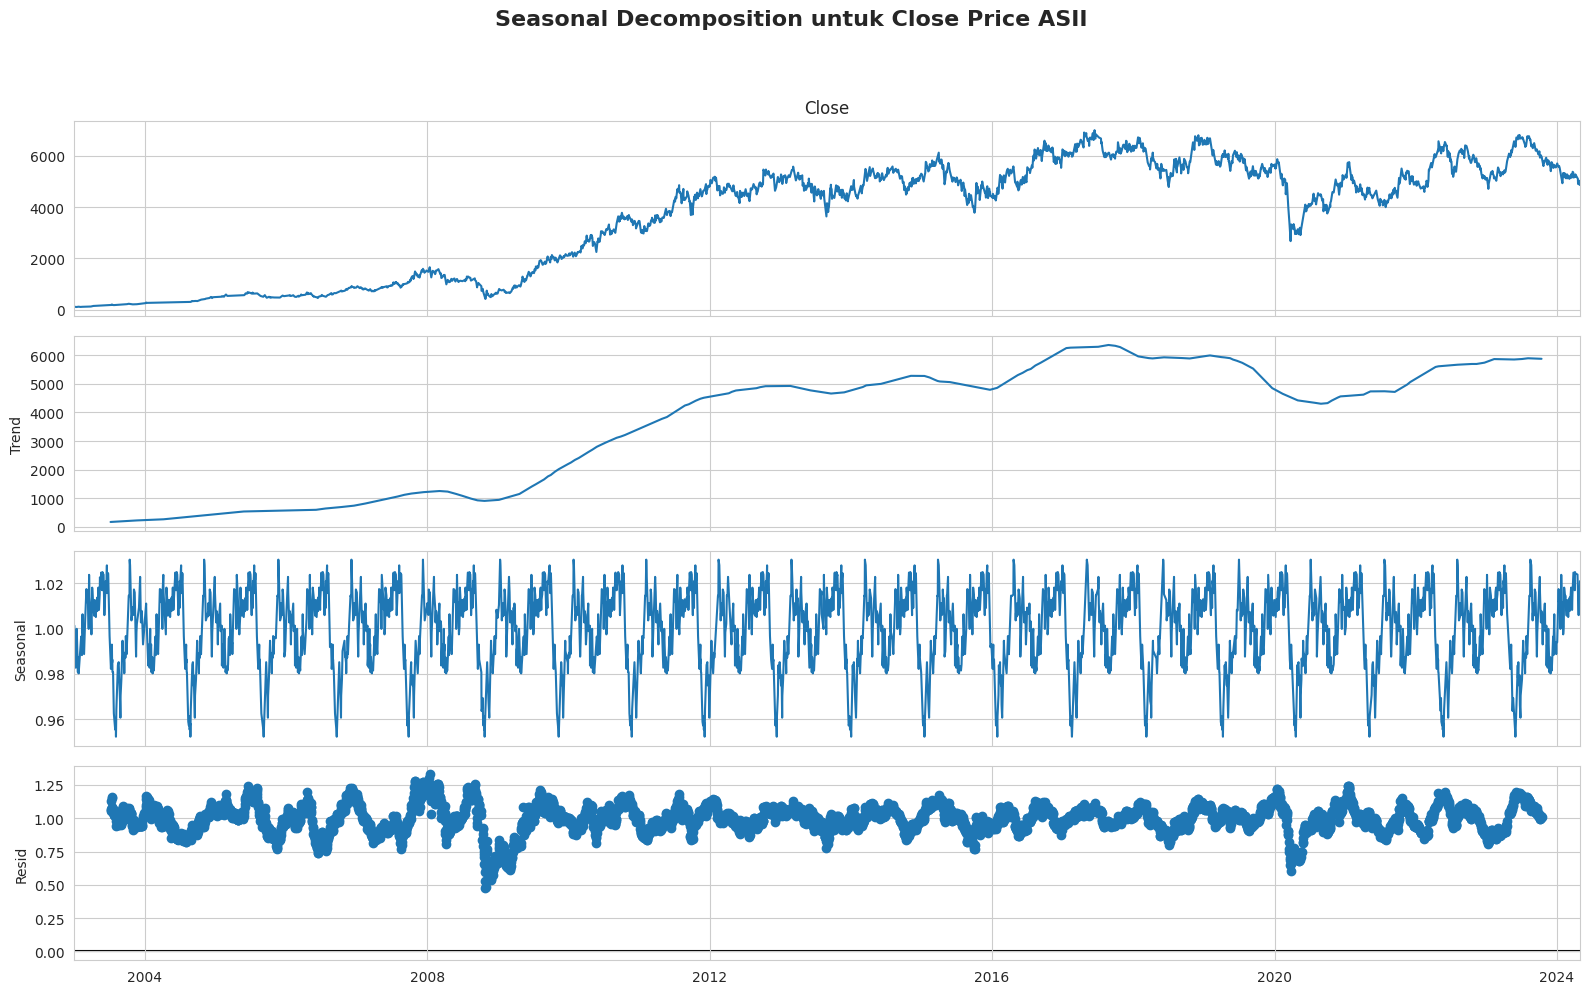

Dekomposisi musiman selesai.


In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')

# Pilih beberapa saham teratas untuk dekomposisi musiman
top_stocks_for_decompose = df['Stock_Name'].value_counts().head(3).index.tolist()

# Tentukan frekuensi musiman
# Misalnya, 252 hari kerja dalam setahun (jika data harian), atau 21 hari kerja dalam sebulan
seasonal_freq = 252 # Asumsi sekitar 252 hari perdagangan dalam setahun

print('Melakukan Dekomposisi Musiman (Seasonal Decomposition) untuk saham:')

for stock in top_stocks_for_decompose:
    stock_df = df[df['Stock_Name'] == stock].set_index('Date').sort_index().copy()

    # Pastikan data tidak memiliki nilai NaN sebelum dekomposisi
    close_price_series = stock_df['Close'].dropna()

    if len(close_price_series) > 2 * seasonal_freq: # Minimal 2 siklus musiman diperlukan
        # Dekomposisi musiman model multiplikatif karena sering lebih cocok untuk data finansial
        decomposition = seasonal_decompose(close_price_series, model='multiplicative', period=seasonal_freq)

        fig = decomposition.plot()
        fig.set_size_inches(16, 10)
        fig.suptitle(f'Seasonal Decomposition untuk Close Price {stock}', y=1.02, fontsize=16)
        plt.tight_layout(rect=[0, 0.03, 1, 0.98])
        plt.show()
    else:
        print(f'  Data Close Price tidak cukup panjang untuk dekomposisi musiman (membutuhkan minimal 2*{seasonal_freq} titik data) untuk {stock}.')

print('Dekomposisi musiman selesai.')

## 9. Analisis Multivariat & Korelasi (The Relationships)



### 9.1 Correlation Heatmap: Hubungan Antar Variabel Numerik



Matriks Korelasi Antar Semua Variabel Numerik dan Fitur Rekayasa:



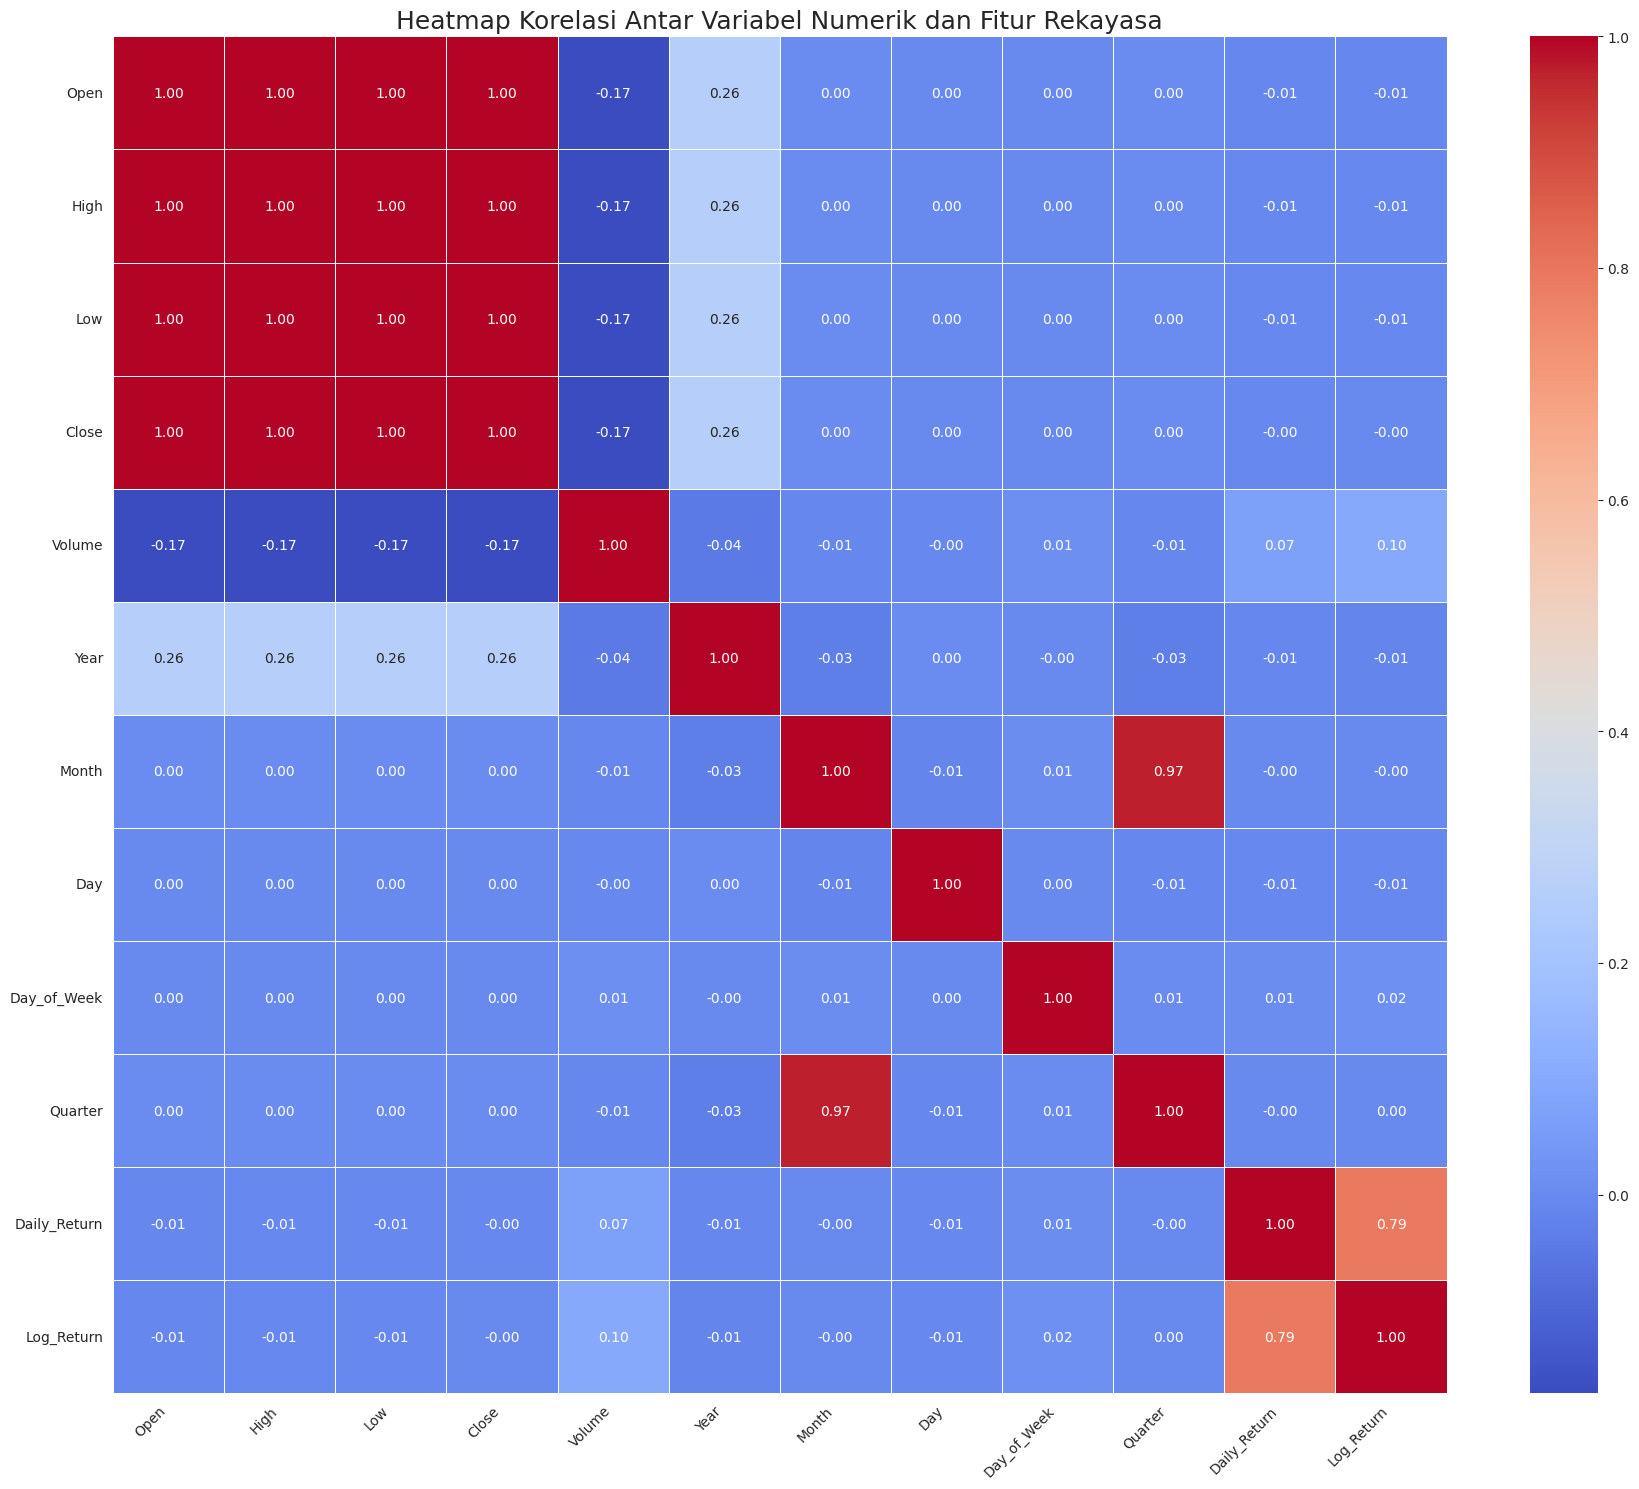


Analisis Correlation Heatmap selesai.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')

# Pilih kolom numerik dan fitur rekayasa yang relevan untuk analisis korelasi
# Termasuk harga, volume, fitur waktu, dan indikator teknis yang baru dibuat
correlation_cols_full = [
    'Open', 'High', 'Low', 'Close', 'Volume',
    'Year', 'Month', 'Day', 'Day_of_Week', 'Quarter',
    'EMA_12', 'EMA_26', 'RSI', 'MACD_Line', 'Signal_Line', 'MACD_Hist',
    'SMA_20', 'Upper_BB', 'Lower_BB', 'Daily_Return', 'Log_Return'
]

# Filter kolom yang benar-benar ada di DataFrame untuk menghindari error
actual_correlation_cols = [col for col in correlation_cols_full if col in df.columns]

# Hitung matriks korelasi
correlation_matrix_full = df[actual_correlation_cols].corr()

print('Matriks Korelasi Antar Semua Variabel Numerik dan Fitur Rekayasa:\n')
# Tampilkan matriks korelasi (opsional, jika matriks terlalu besar)
# print(correlation_matrix_full)

# Visualisasi matriks korelasi menggunakan heatmap
plt.figure(figsize=(18, 15))
sns.heatmap(correlation_matrix_full, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Heatmap Korelasi Antar Variabel Numerik dan Fitur Rekayasa', fontsize=18)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()
plt.show()

print('\nAnalisis Correlation Heatmap selesai.')

### 9.2 Inter-Stock Correlation: Hubungan Antar Saham



Matriks Korelasi Antar Saham (Berdasarkan Log Returns):



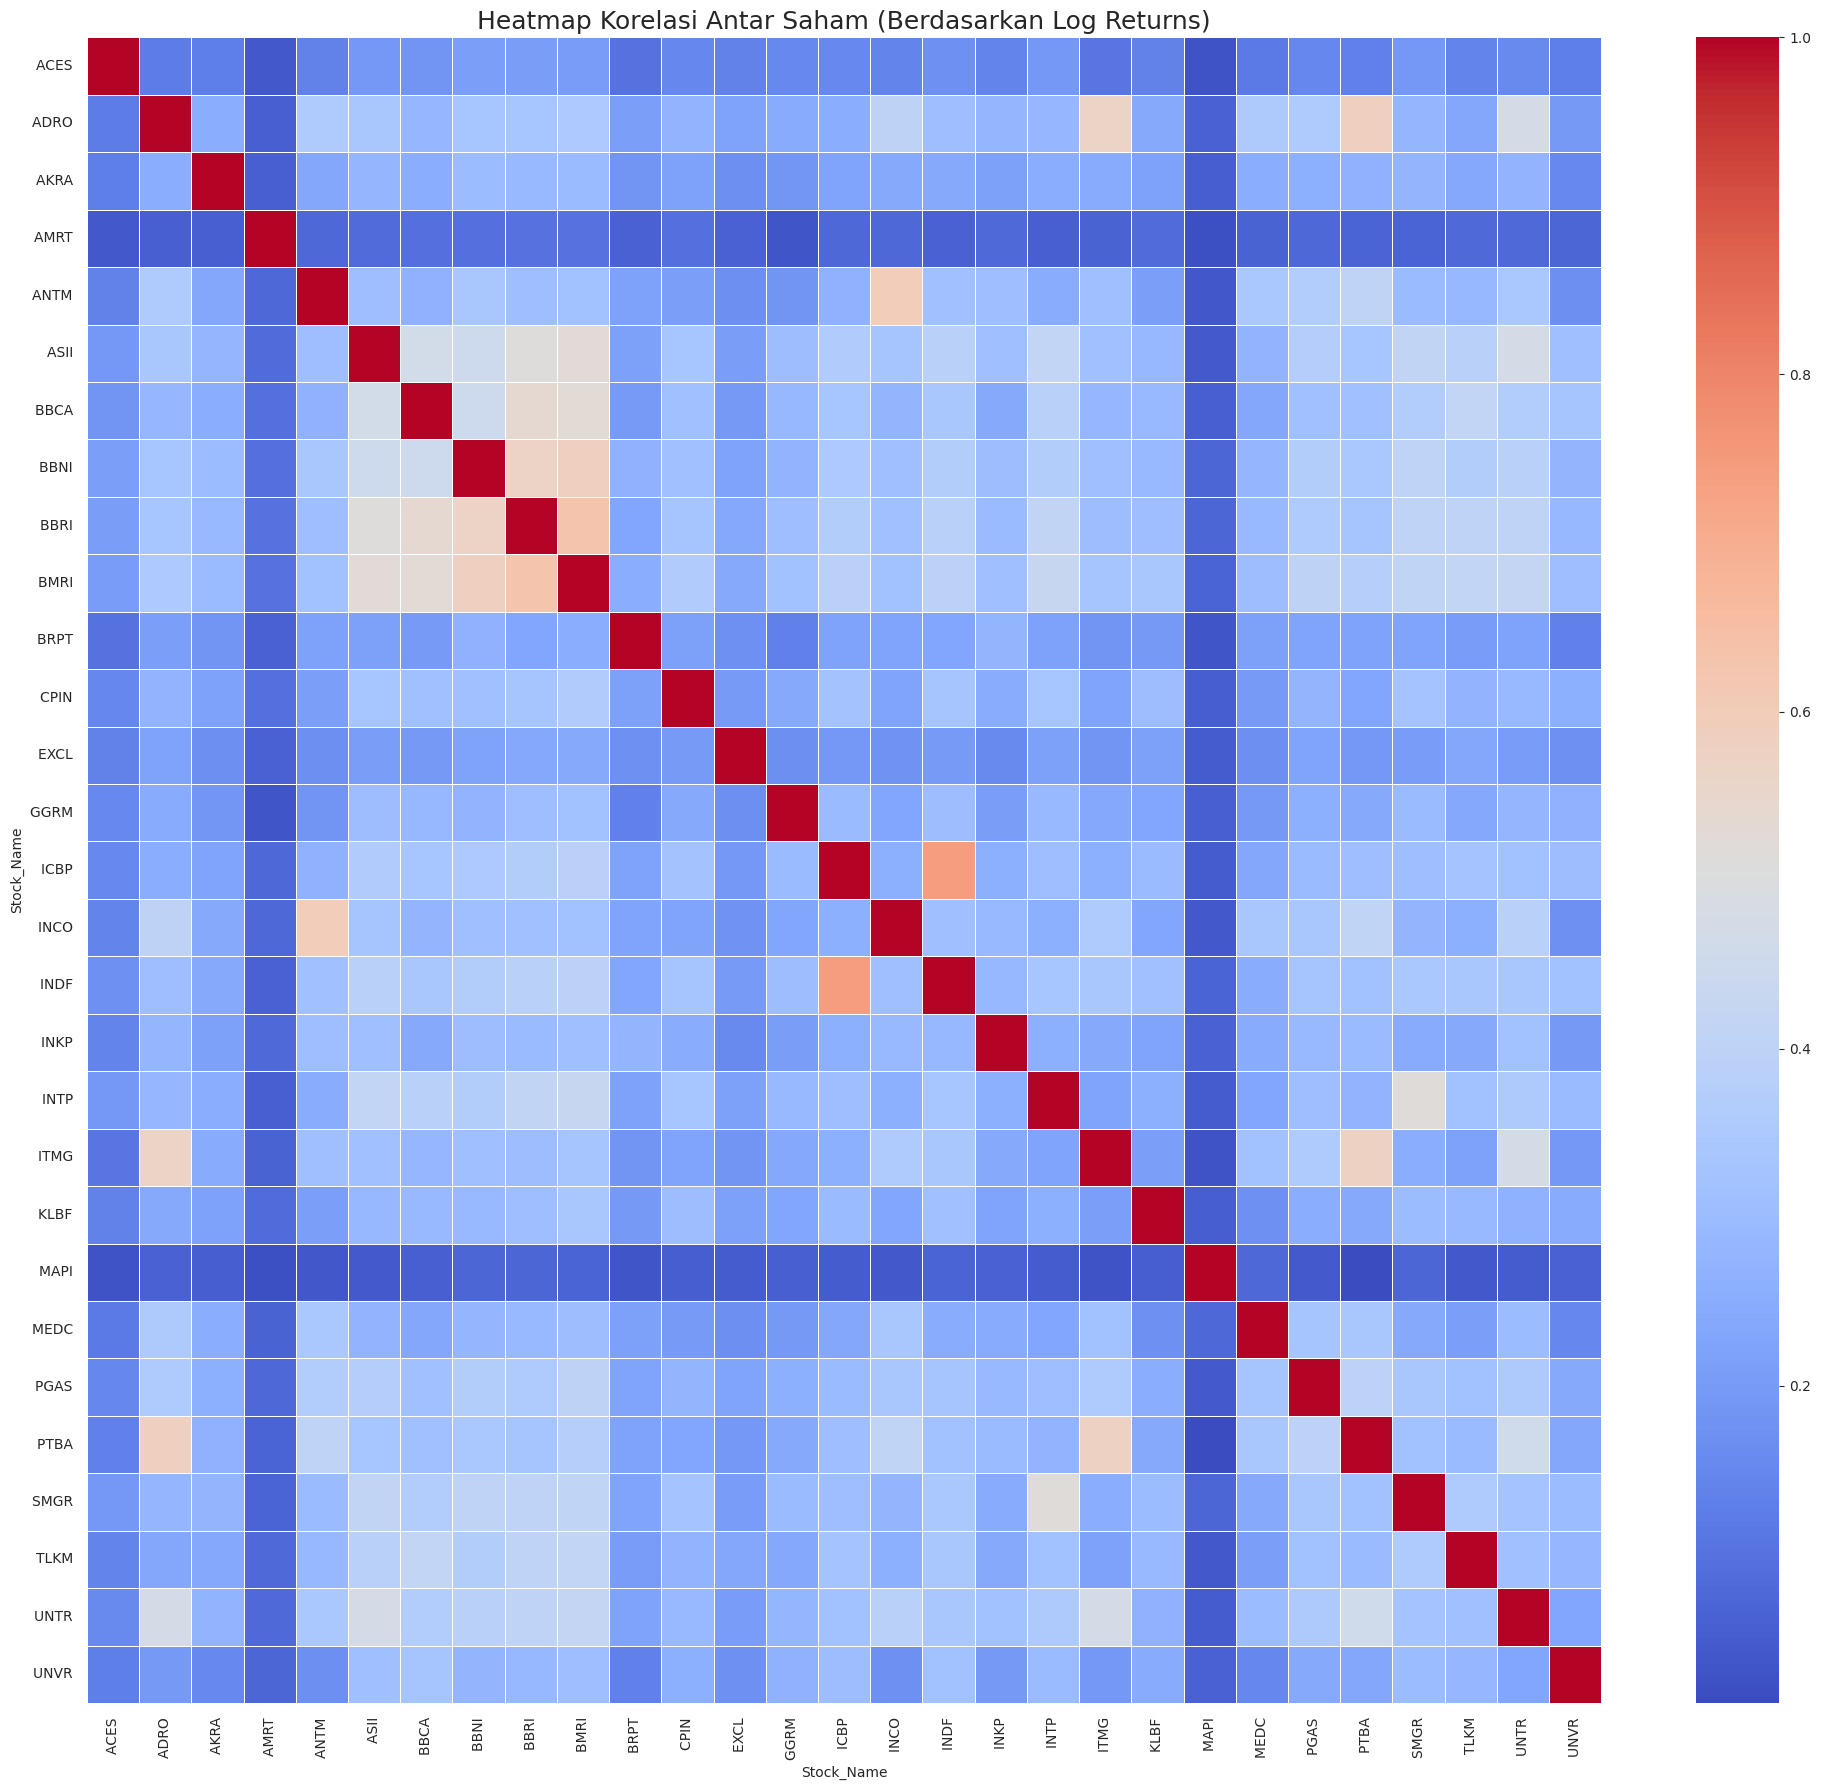


Analisis Inter-Stock Correlation selesai.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')

# Pivot tabel untuk mendapatkan Log_Return per Stock_Name sebagai kolom
# Pastikan df memiliki kolom 'Log_Return' dan 'Stock_Name'
log_returns_pivot = df.pivot_table(index='Date', columns='Stock_Name', values='Log_Return')

# Hitung matriks korelasi antar saham
inter_stock_correlation = log_returns_pivot.corr()

print('Matriks Korelasi Antar Saham (Berdasarkan Log Returns):\n')
# Tampilkan beberapa baris pertama dari matriks korelasi
# print(inter_stock_correlation.head())

# Visualisasi inter-stock correlation menggunakan heatmap
plt.figure(figsize=(20, 18)) # Ukuran disesuaikan karena banyak saham
sns.heatmap(inter_stock_correlation, annot=False, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Heatmap Korelasi Antar Saham (Berdasarkan Log Returns)', fontsize=18)
plt.xticks(rotation=90, fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()
plt.show()

print('\nAnalisis Inter-Stock Correlation selesai.')

### 9.3 Lagged Correlation: Dependensi Temporal



In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')

# Pilih beberapa saham teratas untuk analisis korelasi lag
top_stocks_for_lagged_corr = df['Stock_Name'].value_counts().head(3).index.tolist()

max_lag = 5 # Contoh: menganalisis korelasi hingga 5 hari sebelumnya

print('Melakukan Analisis Lagged Correlation untuk beberapa saham dan variabel:\n')

for stock in top_stocks_for_lagged_corr:
    print(f'--- Saham: {stock} ---')
    stock_df = df[df['Stock_Name'] == stock].set_index('Date').sort_index().copy()

    # Contoh 1: Korelasi antara Daily_Return hari ini dengan Daily_Return N hari sebelumnya
    print('  Korelasi Daily_Return dengan Daily_Return (lagged):')
    lagged_returns_corr = [stock_df['Daily_Return'].autocorr(lag=l) for l in range(1, max_lag + 1)]
    for l, corr in enumerate(lagged_returns_corr):
        print(f'    Lag {l+1} hari: {corr:.4f}')
    print()

    # Contoh 2: Korelasi antara Volume hari ini dengan Daily_Return hari berikutnya
    print('  Korelasi Volume hari ini dengan Daily_Return hari berikutnya:')
    # Shift Daily_Return ke atas (Daily_Return hari 't+1' sejajar dengan Volume hari 't')
    corr_vol_next_return = stock_df['Volume'].corr(stock_df['Daily_Return'].shift(-1))
    print(f'    Volume (t) vs Daily_Return (t+1): {corr_vol_next_return:.4f}')
    print()

    # Contoh 3: Korelasi antara Harga Penutupan hari ini dengan Harga Penutupan N hari sebelumnya (untuk memeriksa stasioneritas)
    print('  Korelasi Close Price dengan Close Price (lagged):')
    lagged_close_corr = [stock_df['Close'].autocorr(lag=l) for l in range(1, max_lag + 1)]
    for l, corr in enumerate(lagged_close_corr):
        print(f'    Lag {l+1} hari: {corr:.4f}')
    print()

print('Analisis Lagged Correlation selesai.')

Melakukan Analisis Lagged Correlation untuk beberapa saham dan variabel:

--- Saham: INDF  ---
  Korelasi Daily_Return dengan Daily_Return (lagged):
    Lag 1 hari: -0.0432
    Lag 2 hari: -0.0181
    Lag 3 hari: -0.0454
    Lag 4 hari: 0.0006
    Lag 5 hari: -0.0133

  Korelasi Volume hari ini dengan Daily_Return hari berikutnya:
    Volume (t) vs Daily_Return (t+1): 0.0364

  Korelasi Close Price dengan Close Price (lagged):
    Lag 1 hari: 0.9994
    Lag 2 hari: 0.9988
    Lag 3 hari: 0.9983
    Lag 4 hari: 0.9979
    Lag 5 hari: 0.9975

--- Saham: GGRM  ---
  Korelasi Daily_Return dengan Daily_Return (lagged):
    Lag 1 hari: 0.0433
    Lag 2 hari: -0.0399
    Lag 3 hari: -0.0495
    Lag 4 hari: -0.0019
    Lag 5 hari: -0.0427

  Korelasi Volume hari ini dengan Daily_Return hari berikutnya:
    Volume (t) vs Daily_Return (t+1): -0.0062

  Korelasi Close Price dengan Close Price (lagged):
    Lag 1 hari: 0.9993
    Lag 2 hari: 0.9985
    Lag 3 hari: 0.9978
    Lag 4 hari: 0.9972
   

## 10. Sintesis & Strategi Pemodelan (The Bridge)

Bagian ini adalah puncak dari seluruh proses *Exploratory Data Analysis (EDA)* yang telah kita lakukan. Di sini, kita akan mengkonsolidasikan semua temuan kunci dari setiap bab analisis, merangkum wawasan yang paling signifikan, dan menerjemahkannya menjadi strategi konkret untuk pembangunan model Machine Learning. Ini adalah jembatan dari pemahaman data ke implementasi prediktif.

### Tujuan Utama:
*   **Merangkum Temuan Kunci**: Mengidentifikasi 3-5 poin terpenting dari seluruh EDA yang akan menjadi dasar keputusan pemodelan.
*   **Rencana Feature Engineering**: Merumuskan fitur-fitur baru yang akan dibuat berdasarkan wawasan dari EDA (misalnya, indikator teknis lanjutan, fitur lag, atau transformasi data).
*   **Justifikasi Pemilihan Model**: Memilih dan membenarkan jenis model Machine Learning yang paling sesuai (misalnya, Regresi Linear, Model Time Series spesifik seperti ARIMA/Prophet, Machine Learning berbasis pohon seperti Random Forest/XGBoost, atau Deep Learning seperti LSTM/GRU) berdasarkan karakteristik data dan tujuan kompetisi.
*   **Strategi Validasi Model**: Menentukan pendekatan validasi yang robust, terutama untuk data deret waktu, untuk menghindari *data leakage* dan memastikan generalisasi model.

### Temuan Kunci dari Analisis Data:

1.  **Struktur Data dan Kualitas**: Dataset berhasil dimuat dengan benar (setelah koreksi separator) dan terbukti memiliki kualitas yang sangat baik dengan **tidak adanya nilai hilang (missing values)** dan **tidak adanya baris duplikat**. Kolom `Date` telah berhasil dikonversi ke tipe datetime.
2.  **Feature Engineering Waktu**: Kolom `Date` telah berhasil diekstrak menjadi berbagai fitur berbasis waktu (`Year`, `Month`, `Day`, `Day_of_Week`, `Quarter`, dll.) yang sangat penting untuk menangkap pola temporal dan musiman dalam data saham.
3.  **Distribusi Variabel Numerik (`Open`, `High`, `Low`, `Close`, `Volume`)**: Semua kolom harga dan `Volume` memiliki distribusi yang sangat **condong ke kanan (right-skewed)** dan **banyak outlier** dengan nilai yang sangat tinggi. Ini mengindikasikan bahwa sebagian besar data berada pada nilai rendah, namun ada kejadian-kejadian signifikan yang perlu dicermati. Nilai minimum harga `5` IDR juga menarik perhatian.
4.  **Distribusi Variabel Kategorikal (`Stock_Name`)**: Terdapat **29 saham unik** dalam dataset, dengan beberapa saham memiliki frekuensi data yang sangat tinggi (`INDF`, `GGRM`, `ASII`, dll.), menunjukkan representasi yang lebih banyak dalam historis data.
5.  **Analisis Deret Waktu**: Visualisasi tren harga penutupan dan volume perdagangan untuk saham-saham teratas menunjukkan **variasi yang signifikan** antar saham dan tren yang jelas. Analisis pola bulanan dan mingguan mengindikasikan fluktuasi dalam rata-rata harga penutupan dan volume perdagangan berdasarkan periode waktu tertentu.
6.  **Korelasi Antar Variabel Numerik**: Kolom harga (`Open`, `High`, `Low`, `Close`) memiliki korelasi yang sangat kuat (mendekati 1.00) satu sama lain. `Volume` menunjukkan korelasi negatif yang lemah dengan harga saham dan fitur waktu. `Year` menunjukkan korelasi positif yang lemah dengan harga, menyiratkan tren kenaikan harga secara historis. `Month`, `Day_of_Week`, dan `Quarter` menunjukkan korelasi yang sangat lemah dengan variabel harga dan volume.
7.  **Analisis Pengembalian Harian (Daily Returns)**: Distribusi *daily returns* menunjukkan rentang yang luas dengan *outlier* yang signifikan, baik positif maupun negatif, mengindikasikan volatilitas yang tinggi dan *fat-tailed distribution*. Rata-rata *daily return* positif, tetapi standar deviasinya besar, menyoroti risiko yang melekat. *Volatility clustering* terlihat jelas dari plot *squared daily returns*.
8.  **Diagnostik Deret Waktu Tingkat Lanjut**: Uji ADF menunjukkan bahwa *Close Price* adalah non-stasioner, sedangkan *Log Returns* adalah stasioner, yang mendukung penggunaan *returns* untuk pemodelan deret waktu. Plot ACF dan PACF untuk *Log Returns* menunjukkan korelasi yang cepat menurun, mengindikasikan dependensi jangka pendek. Dekomposisi musiman menunjukkan komponen tren yang dominan dan pola musiman yang konsisten untuk beberapa saham.
9.  **Korelasi Lanjut**: *Correlation Heatmap* menunjukkan hubungan kompleks antar fitur. *Inter-Stock Correlation* mengungkapkan kelompok saham yang bergerak searah. *Lagged Correlation* memberikan wawasan tentang dependensi harga atau volume di masa lalu terhadap pergerakan saat ini/mendatang.

### Strategi Komprehensif untuk Lomba:

Berdasarkan temuan di atas, berikut adalah strategi terperinci untuk memaksimalkan potensi keberhasilan dalam lomba:

#### 1. Data Preprocessing Lanjutan:
*   **Penanganan Outlier**: Mengingat banyaknya *outlier* yang teridentifikasi, terutama pada `Volume` dan kolom harga, perlu dilakukan investigasi mendalam. Pertimbangkan metode *Winsorization*, *trimming*, atau transformasi logaritmik, terutama untuk `Volume`. Keputusan harus didasarkan pada apakah outlier tersebut adalah anomali data atau representasi peristiwa pasar yang penting.
*   **Normalisasi/Standardisasi**: Fitur numerik dengan skala yang sangat berbeda (misalnya, `Volume` vs. `Close`) harus dinormalisasi atau distandardisasi sebelum dimasukkan ke model Machine Learning, terutama model yang sensitif terhadap skala (misalnya, Regresi Linear, SVM, Jaringan Saraf Tiruan).
*   **Penanganan Saham dengan Data Sedikit**: Saham dengan jumlah entri data yang sangat sedikit mungkin perlu diperlakukan berbeda atau bahkan dikecualikan dari analisis model jika tidak cukup representatif.

#### 2. Feature Engineering yang Lebih Lanjut (Indikator Teknis):
*   **Indikator Teknis Saham**: Indikator-indikator seperti **Moving Averages (SMA/EMA)**, **Relative Strength Index (RSI)**, **Moving Average Convergence Divergence (MACD)**, dan **Bollinger Bands** telah berhasil dihitung. Ini akan menjadi fitur yang sangat krusial dalam analisis saham untuk mengidentifikasi tren, momentum, dan volatilitas.
*   **Lagged Features**: Buat fitur *lagged* untuk harga penutupan, volume, atau indikator teknis tertentu untuk menangkap dependensi waktu yang signifikan, sesuai dengan hasil analisis *Lagged Correlation*.
*   **Daily Returns**: Gunakan *daily returns* atau *log returns* sebagai target prediksi atau sebagai fitur untuk memprediksi perubahan harga, bukan hanya harga absolut.

#### 3. Pendekatan Analisis dan Pemodelan:
*   **Analisis Time Series Mendalam**: Manfaatkan hasil uji stasioneritas, ACF, PACF, dan dekomposisi musiman untuk memilih dan mengkonfigurasi model deret waktu yang tepat.
*   **Model Machine Learning**: Pertimbangkan untuk membangun dan membandingkan beberapa jenis model:
    *   **Traditional Time Series Models**: ARIMA, SARIMA (jika ada musiman yang kuat), Exponential Smoothing, untuk *baseline*.
    *   **Machine Learning Models**: Random Forest, Gradient Boosting Machines (XGBoost, LightGBM) karena kemampuannya menangani non-linearitas dan interaksi fitur, serta cenderung robust terhadap outlier setelah preprocessing yang tepat.
    *   **Deep Learning Models**: LSTM (Long Short-Term Memory) atau GRU (Gated Recurrent Unit) adalah pilihan yang sangat kuat untuk data deret waktu karena kemampuannya menangkap dependensi jangka panjang dan pola kompleks. Ini mungkin memberikan kinerja terbaik jika diimplementasikan dengan benar.
*   **Target Prediksi**: Tentukan dengan jelas apa yang akan diprediksi: harga penutupan berikutnya, arah pergerakan harga (klasifikasi naik/turun), atau *daily returns*. Sesuaikan model (regresi vs. klasifikasi) dengan target ini.

#### 4. Validasi Model yang Robust:
*   **Time Series Cross-Validation**: **Jangan gunakan k-fold cross-validation standar** karena akan menyebabkan *data leakage*. Gunakan teknik validasi silang yang sesuai untuk deret waktu, seperti *walk-forward validation* atau *time series split*.
*   **Metrik Evaluasi**: Selalu sesuaikan metrik evaluasi dengan tujuan kompetisi yang disebutkan dalam `PANDUAN DATA ANALYSIS COMPETITION.pdf`. Untuk regresi, gunakan RMSE, MAE, R-squared. Untuk klasifikasi, gunakan Akurasi, Presisi, Recall, F1-Score, AUC-ROC.

#### 5. Eksplorasi Lebih Lanjut dan Iterasi:
*   **Analisis Sektoral/Kelompok Saham**: Jika memungkinkan, kelompokkan saham berdasarkan sektor atau karakteristik tertentu dan lakukan analisis terpisah untuk setiap kelompok. Mungkin ada model yang lebih cocok untuk sektor tertentu.
*   **Analisis Sentimen**: Jika ada data tambahan (misalnya, berita keuangan, media sosial), analisis sentimen dapat menjadi fitur yang sangat kuat.
*   **Iterasi**: Proses ini bersifat iteratif. Mulai dengan model dasar, evaluasi, lakukan *feature engineering* lebih lanjut, sesuaikan *preprocessing*, dan ulangi sampai kinerja optimal tercapai.

Dengan strategi yang terstruktur dan didukung oleh analisis data yang mendalam ini, Anda memiliki jalur yang jelas menuju keberhasilan dalam lomba. Siap untuk melangkah ke implementasi, Profesor!